# Environment Preperation

In [ ]:
HOME_PATH = "/content/drive/MyDrive"

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
HOME_PATH = "/content/drive/MyDrive"

KeyboardInterrupt: ignored

In [ ]:
import importlib

# List of packages to install
packages = ['emoji', 'transformers', 'nltk', 'joblib']

for package in packages:
    try:
        importlib.import_module(package)
        print(f"{package} is already installed.")
    except ImportError:
        print(f"{package} is not installed. Installing...")
        !pip install {package}

# Data Preparation

### File Reading

In [ ]:
path_to_l_list_tweets = f"{HOME_PATH}/account-tweet/l_list_tweets.csv"
path_to_l_list_accounts = f"{HOME_PATH}/account-tweet/l_list_accounts.csv"

path_to_random_list_tweets = f"{HOME_PATH}/account-tweet/random_users_tweets.csv"
path_to_random_list_accounts = f"{HOME_PATH}/account-tweet/random_users_accounts.csv"

In [ ]:
import pandas as pd

l_list_tweets_df = pd.read_csv(path_to_l_list_tweets, usecols=['account_id', 'created_at', 'full_text', 'quote_count', 'reply_count', 'retweet_count', 'favorite_count', 'bookmark_count', 'mentions', 'lang'])
l_list_accounts_df = pd.read_csv(path_to_l_list_accounts, usecols=['rest_id', 'created_at', 'description', 'favourites_count', 'followers_count', 'friends_count', 'statuses_count', 'screen_name'])

random_list_tweets_df = pd.read_csv(path_to_random_list_tweets, usecols=['account_id', 'created_at', 'full_text', 'quote_count', 'reply_count', 'retweet_count', 'favorite_count', 'bookmark_count', 'mentions', 'lang'])
random_list_accounts_df = pd.read_csv(path_to_random_list_accounts, usecols=['rest_id', 'created_at', 'description', 'favourites_count', 'followers_count', 'friends_count', 'statuses_count', 'screen_name'])

user_tweets_df = pd.concat([l_list_tweets_df, random_list_tweets_df], ignore_index=True)
user_accounts_df =  pd.concat([l_list_accounts_df, random_list_accounts_df], ignore_index=True)


FileNotFoundError: ignored

### Data Creation

In [ ]:
from collections import defaultdict
import re

def df_to_user_dict(df,user_primary_key_name):

    user_grouped_df = df.groupby(user_primary_key_name)

    user_dict = {}
    for user_id, group in user_grouped_df:
        group_dict = group.drop(user_primary_key_name, axis=1).to_dict('records')
        user_dict[str(user_id)] = group_dict

    return user_dict

def combine_user_account_and_tweets_dicts(user_account_dict, user_tweets_dict):
    user_dict = {}
    tweets_not_found_for_user = 0
    for user_id, info in user_account_dict.items():
        try:
            user_dict[user_id] = {'info':info, 'tweets':user_tweets_dict[user_id]}
        except:
            tweets_not_found_for_user+=1

    return user_dict, tweets_not_found_for_user

def user_tweets_dict_to_user_documents(user_tweets_dict):
    documents = {}
    user_tweet_contents = defaultdict()
    for user, tweets in user_tweets_dict.items():
        user_tweets_full_text = []
        user_tweet_contents[user] = {'originals': [], 'retweets': [], 'replies': []}

        for tweet in tweets:
            tweet_full_text = tweet['full_text']
            user_tweets_full_text.append(tweet_full_text)

            user_tweet_contents[user][detect_tweet_type(tweet_full_text)].append(tweet_full_text)

        documents[user]= (" ".join(user_tweets_full_text))

    return documents, user_tweet_contents


def detect_tweet_type(tweet):
    tweet = tweet.strip()
    if re.match(r'^RT @.*', tweet):
        return "retweets"
    elif re.match(r'^@.*', tweet):
        # Extract the username from the tweet
        username = tweet.split(' ')[0].lstrip('@')
        if len(username) > 0:
            return "replies"
    return "originals"

In [ ]:
users_tweets_dict = df_to_user_dict(user_tweets_df, 'account_id')
users_account_dict = df_to_user_dict(user_accounts_df, 'rest_id')
#l_users_total_dict, num_users_tweets_not_found = combine_user_account_and_tweets_dicts(l_users_account_dict, l_users_tweets_dict)
users_documents, users_typed_documents = user_tweets_dict_to_user_documents(users_tweets_dict)

In [ ]:
account_screen_name_id = {}
for id,x in users_account_dict.items():
  account_screen_name_id[x[0]['screen_name']] = id

account_id_screen_name = {}
for id,x in users_account_dict.items():
  account_id_screen_name[id] = x[0]['screen_name']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
# Extra Features
import json
import numpy as np

IGNORE_FEATURE_NAMES = ['retrieved_retweet_count', 'retrieved_authored_tweet_count']

# Read the JSON file
with open(f'{HOME_PATH}/users_extra_features.json') as json_file:
    users_extra_features = json.load(json_file)

users_extra_features = json.loads(users_extra_features)
# Extract the user IDs and feature values
user_ids = list(users_extra_features.keys())
user_ids = [account_screen_name_id[user] for user in user_ids]
feature_values = list(users_extra_features.values())

# Create a feature dictionary
feature_dict = {}
for features in feature_values:
    for feature_name in features.keys():
      if feature_name in IGNORE_FEATURE_NAMES:
        continue
      else:
        if feature_name not in feature_dict:
            feature_dict[feature_name] = len(feature_dict)

# Initialize the user vectors list
user_vectors = []

# Iterate over the user data
for features in feature_values:
    user_vector = np.zeros(len(feature_dict))
    for feature_name, feature_value in features.items():
      if feature_name in IGNORE_FEATURE_NAMES:
        continue
      feature_index = feature_dict[feature_name]
      if np.isnan(feature_value):
          feature_value = 0
      user_vector[feature_index] = feature_value
    user_vectors.append(user_vector)

# Convert the user vectors list to a NumPy array
extra_user_vectors = np.array(user_vectors)

# Normalize the extra_user_vectors

scaler = StandardScaler()
normalized_extra_user_vectors = scaler.fit_transform(extra_user_vectors)

normalizer = Normalizer(norm='l2')
normalized_extra_user_vectors = normalizer.fit_transform(normalized_extra_user_vectors)

normalized_extra_user_vectors = [0.2 * vector for vector in normalized_extra_user_vectors]

# Create a dictionary to store the normalized extra features
extra_features = {}
for user, vector in zip(user_ids, normalized_extra_user_vectors):
    extra_features[user] = vector

### Text PreProcessing

In [ ]:
import re
import emoji
import string
import nltk
from nltk.tokenize import RegexpTokenizer, word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.corpus import wordnet

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


stop_words_file = set()
with open(f"{HOME_PATH}/turkish-stop_words.txt", 'r') as file:
    # Read each line of the file
    for line in file:
        # Remove leading/trailing whitespace and add the word to the set
        word = line.strip()
        stop_words_file.add(word)
STOP_WORDS = set(stopwords.words('turkish'))
STOP_WORDS = STOP_WORDS.union(stop_words_file)

def stop_word_remover(text):
    # Tokenize the text into words
    words = word_tokenize(text, language='turkish')

    # Remove Turkish stop words
    filtered_words = [word for word in words if (word.lower().replace('i̇', 'i') not in STOP_WORDS)]

    # Join the filtered words back into a sentence
    filtered_text = ' '.join(filtered_words)

    return filtered_text


def pre_process_light(text):
    # Remove URLs using regex
    text = re.sub(r'\bhttps?\B*', ' ', text)
    text = re.sub(r'https?://\S+|\n|\\|\'', ' ', text)
    text = re.sub(r'\b\w*http\w*\b', ' ', text)

    # Remove backshalshed symbols using regex
    text = re.sub(r'\n|\\|\'', ' ', text)

    # Remove emojis
    emojis_textualized = emoji.demojize(text)
    text = re.sub(r':[a-zA-Z_]+:', ' ', emojis_textualized)

    # Remove punctuations
    punctuation = string.punctuation.replace('@', '')
    translator = str.maketrans('', '', punctuation)
    text = text.translate(translator).replace('…', ' ').replace("“", ' ').replace("”", ' ').replace('’', ' ')

    # Remove multiple spaces and lower
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def pre_process_heavy(text):
    # Remove URLs using regex
    text = re.sub(r'\bhttp\S*', ' ', text)
    text = re.sub(r'https?://\S+|\n|\\|\'', ' ', text)
    text = re.sub(r'\b\w*http\w*\b', ' ', text)

    # Remove backshalshed symbols using regex
    text = re.sub(r'\n|\\', ' ', text)

    # Remove RTs and mentions
    text = re.sub(r'\bRT\b', ' ', text)
    text = re.sub(r'@[A-Za-z0-9_]+:?', ' ', text)

    # Concatenate suffix
    text = text.replace("'", "").replace('’', '').replace("‘",'').replace("‘","")

    # Remove punctuations
    punctuation = string.punctuation
    translator = str.maketrans('', '', punctuation)
    text = text.translate(translator).replace('…', ' ').replace("“", ' ').replace("”", ' ')

    # Tokenize and separate with space
    separated_text = re.findall(r'\w+|\S', text)
    text = " ".join(separated_text)

    # Remove Turkish stop words
    text = stop_word_remover(text)

    # Convert emojis to words
    emojis_textualized = emoji.demojize(text)
    text = emojis_textualized.replace(':',' ') #re.sub(r':[a-zA-Z_]+:', ' ', emojis_textualized)

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip().lower().replace('i̇', 'i').replace('î', 'i')

    return text

def pre_process_emojized_heavy(text):
    # Remove URLs using regex
    text = re.sub(r'\bhttp\S*', ' ', text)
    text = re.sub(r'https?://\S+|\n|\\|\'', ' ', text)
    text = re.sub(r'\b\w*http\w*\b', ' ', text)

    # Remove backshalshed symbols using regex
    text = re.sub(r'\n|\\|\'', ' ', text)

    # Remove RTs and mentions
    text = re.sub(r'\bRT\b', ' ', text)
    text = re.sub(r'@[A-Za-z0-9_]+:?', ' ', text)

    # Concatenate suffix
    text = text.replace("'", "").replace('’', '')

    # Remove punctuations
    punctuation = string.punctuation
    translator = str.maketrans('', '', punctuation)
    text = text.translate(translator).replace('…', ' ').replace("“", ' ').replace("”", ' ')

    # Tokenize and separate with space
    separated_text = re.findall(r'\w+|\S', text)
    text = " ".join(separated_text)

    # Remove Turkish stop words
    text = stop_word_remover(text)

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip().lower().replace('i̇', 'i')

    return text


def clear_docs(documents, preprocess_type='heavy'):
    if preprocess_type == 'light':
        pp = pre_process_light
    elif preprocess_type == 'emojized_heavy':
      pp = pre_process_emojized_heavy
    else:
        pp = pre_process_heavy

    if isinstance(documents, str):
        return pp(documents)
    elif isinstance(documents, list):
        return [clear_docs(text, preprocess_type) for text in documents]
    elif isinstance(documents,dict):
        for user, doc in documents.items():
            if isinstance(doc,str):
                documents[user] = clear_docs(doc, preprocess_type)
            elif isinstance(doc,dict):
                for typ, value in doc.items():
                    doc[typ] = clear_docs(value, preprocess_type)

    return documents


In [ ]:
import copy
def create_users_pp_documents(preprocess_type='heavy'):
  users_pp_documents  = clear_docs(copy.deepcopy(users_documents),preprocess_type)
  return users_pp_documents
def create_users_typed_documents(preprocess_type='heavy'):
  users_pp_typed_documents= clear_docs(copy.deepcopy(users_typed_documents),preprocess_type)
  return users_pp_typed_documents

In [ ]:
def get_users_pp_type_x(users_pp_typed_documents, type_x= "retweets", ):
  users_pp_type_x = {}
  for user, docs in users_pp_typed_documents.items():
    users_pp_type_x[user] = " ".join(docs[type_x])
  print("Len: ", len(users_pp_type_x.keys()))
  return users_pp_type_x

In [ ]:
users_pp_documents = create_users_pp_documents()

In [ ]:
users_pp_typed_documents = create_users_typed_documents("heavy")
# user_retweets = get_users_pp_type_x(users_pp_typed_documents, type_x = "retweets")

# Encoded Annotations

## Functions

In [ ]:
import pandas as pd

def create_annotation_to_label():
  # Read the CSV file into a DataFrame
  annotations = pd.read_csv(f"{HOME_PATH}/all_users_annotations.csv")
  annotations = dict(zip(annotations['User'], annotations['Annotation']))
  data = annotations
  # Update the dictionary values
  for key, value in data.items():
      if value in ['Bot', 'Troll Boğaziçi']:
          data[key] = 'Troll General'

  return annotations

  # Create User_id annotations and User_name annotations Dicts
  def is_all_digits(value):
      if isinstance(value, str):
          return value.isdigit()
      elif isinstance(value, (int, float)):
          return str(value).isdigit()
      return False

  user_id_annotation = {}
  num_of_users_account_info_was_not_retrieved = 0
  for user, annotation in annotations.items():
      if is_all_digits(user):
          user_id_annotation[str(user)] = annotation
      else:
        try:
          user_id_annotation[account_screen_name_id[user]] = annotation
        except:
          num_of_users_account_info_was_not_retrieved += 1


  annotations = user_id_annotation

  print(annotations.keys())
  print(num_of_users_account_info_was_not_retrieved)

  # Get the unique labels
  data = annotations
  labels = list(set(data.values()))

  # Create a mapping for label encoding
  label_mapping = {label: 0 if label == labels[0] else 1 for label in labels}

  # Create a new dictionary to store the encoded data
  encoded_dict = {}
  for key, label in data.items():
      encoded_label = label_mapping[label]
      encoded_dict[key] = encoded_label
  print(encoded_dict['1177970967680835584'])

  import json
  # File path to save the JSON file
  json_file_path = f"{HOME_PATH}/encoded_annotations_user_id.json"

  # Write the dictionary to the JSON file
  """
  with open(json_file_path, 'w') as json_file:
      json.dump(encoded_dict, json_file)
      pass
  """



In [ ]:
annotations = create_annotation_to_label()

In [ ]:
troll_count = sum(1 for value in annotations.values() if value == 'Troll General')
not_troll_count = sum(1 for value in annotations.values() if value == 'Not Troll')

print("Troll count:", troll_count)
print("Not troll count:", not_troll_count)


Troll count: 600
Not troll count: 449


In [ ]:
import random
import json

# Assuming you have the dictionary of labels named 'encoded_dict'
def create_and_write_splits():
  json_file_path = f"{HOME_PATH}/encoded_annotations_user_id.json"
  # Write the dictionary to the JSON file
  with open(json_file_path, 'r') as json_file:
      encoded_dict = json.load(json_file)
  print(encoded_dict['1177970967680835584'])
  # Get all the keys from the dictionary
  keys = list(encoded_dict.keys())

  # Shuffle the keys randomly
  random.shuffle(keys)
  random.shuffle(keys)

  # Calculate the split indices based on the desired split ratios
  train_split = int(0.8 * len(keys))
  val_split = int(0.1 * len(keys))

  # Split the keys into train, validation, and test sets
  train_keys = keys[:train_split]
  val_keys = keys[train_split:train_split+val_split]
  test_keys = keys[train_split+val_split:]

  # Create the train, validation, and test dictionaries
  train_labels = {key: encoded_dict[key] for key in train_keys}
  val_labels = {key: encoded_dict[key] for key in val_keys}
  test_labels = {key: encoded_dict[key] for key in test_keys}

  # Define the paths to save the train, validation, and test JSON files
  train_file_path = f"{HOME_PATH}/train_labels_encoded.json"
  val_file_path = f"{HOME_PATH}/val_labels_encoded.json"
  test_file_path = f"{HOME_PATH}/test_labels_encoded.json"

  # Save the train labels as JSON
  with open(train_file_path, 'w') as file:
      json.dump(train_labels, file)

  # Save the validation labels as JSON
  with open(val_file_path, 'w') as file:
      json.dump(val_labels, file)

  # Save the test labels as JSON
  with open(test_file_path, 'w') as file:
      json.dump(test_labels, file)

def load_splits():
  # Define the paths to save the train, validation, and test JSON files
  train_file_path = f"{HOME_PATH}/train_labels_encoded.json"
  val_file_path = f"{HOME_PATH}/val_labels_encoded.json"
  test_file_path = f"{HOME_PATH}/test_labels_encoded.json"

  # Save the train labels as JSON
  with open(train_file_path, 'r') as file:
     train_labels =json.load(file)

  # Save the validation labels as JSON
  with open(val_file_path, 'r') as file:
      val_labels= json.load(file)

  # Save the test labels as JSON
  with open(test_file_path, 'r') as file:
      test_labels=json.load(file)

  val_labels['271271925'] = 0
  val_labels['534240275'] = 0
  val_labels['3430994307'] = 0
  val_labels['1039933372196446208'] = 0
  val_labels['1248743291551731714'] = 0
  val_labels['1308454163513315343'] = 0
  val_labels['1465401767399763979'] = 0

  test_labels['535511254'] = 0


  return train_labels, val_labels, test_labels



## Load

In [ ]:
train_labels, val_labels, test_labels = load_splits()

troll= 0
nontroll = 0
for k,v in train_labels.items():
  if v == 0:
    nontroll += 1
  elif v ==1:
    troll += 1
  else:
    print('wtf')
troll,nontroll

# BERT

## Create Pipeline

In [ ]:
from transformers import BertModel, BertTokenizer
import torch
import time
# Instantiate the BERT model and tokenizer for Turkish
model = BertModel.from_pretrained("dbmdz/distilbert-base-turkish-cased")
tokenizer = BertTokenizer.from_pretrained("dbmdz/distilbert-base-turkish-cased")

# set device to GPU
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# put model on GPU (is done in-place)
#model.to(device)

# Set the model to evaluation mode
model.eval()

In [ ]:
def doc2vec(input_text):
    # Tokenize the input text
    input_ids = tokenizer.encode(input_text, add_special_tokens=True)

    # Convert the input to PyTorch tensors
    input_tensor = torch.tensor([input_ids])  # No device assignment here

    max_length = 512
    total_entries = input_tensor.shape[1]
    num_tensors = (total_entries - 1) // max_length + 1  # Calculate the number of tensors

    # Create an empty tensor to store the output embeddings
    pooled_outputs = torch.empty([0, 768])#.to(device)

    # Split the tensor into multiple tensors with maximum length 512
    for i in range(num_tensors):
        start_idx = i * max_length
        end_idx = min((i + 1) * max_length, total_entries)
        tensor = input_tensor[:, start_idx:end_idx]#.to(device)  # Move to GPU device

        # Extract the output embeddings or other desired outputs
        embeddings = model(tensor)[1]  # Pooled output
        pooled_outputs = torch.cat([pooled_outputs, embeddings], dim=0)
        torch.cuda.empty_cache()

    # Calculate the mean of the output embeddings
    average_tensor = torch.mean(pooled_outputs, dim=0)

    return average_tensor


## Create BERT Embedding Vectors

In [ ]:
import json
from tqdm import tqdm
import time
import itertools

sliced_iter = itertools.chain(users_pp_documents, len(users_pp_documents.keys())  # Selecting the first n items

for i, user_doc  in enumerate(tqdm(sliced_iter)):
  # Create a dictionary with the ID as the key and tensor list as the value
  user, doc = user_doc
  data = {user: doc2vec(doc).tolist()}
  # Clear GPU cache
  torch.cuda.empty_cache()
  filename = f"{HOME_PATH}/full_vectors/user_{i}.json"
  # Write the data to a JSON file
  with open(filename, 'w+') as file:
      json.dump(data, file)



## Create Concatenated Vectors

In [ ]:
import json
import os

total_users = 981

# Directory paths for the three feature directories
dir1_path = "/content/drive/MyDrive/retweet_vectors_"
dir2_path = "/content/drive/MyDrive/original_vectors_"
dir3_path = "/content/drive/MyDrive/reply_vectors_"

combined_vectors = {}
# Traverse the directories
for i in range(0, total_users + 1):
    user_id = f"user_{i}"
    vector = []

    # Read the vectors from each directory
    for dir_path in [dir1_path, dir2_path, dir3_path]:
        file_path = os.path.join(dir_path, f"{user_id}.json")
        with open(file_path, "r") as file:
            data = json.load(file)
            vector.extend(list(data.values())[0])

    combined_vectors[list(data.keys())[0]] = vector


# Save the combined vectors to a single JSON file
with open("/content/drive/MyDrive/concatenated_vectors.json", "w") as output_file:
    json.dump(combined_vectors, output_file)


## NN Model For Bert Features -- Bad

### Load Training Data with BERT Vectors

In [ ]:
HOME_PATH = "/content/drive/MyDrive"

In [ ]:
import json

# Load the data from the JSON file
with open(f"{HOME_PATH}/train_labels_encoded.json", "r") as file:
    train_labels = json.load(file)

# Load the data from the JSON file
with open(f"{HOME_PATH}/val_labels_encoded.json", "r") as file:
    val_labels = json.load(file)


# Load the data from the JSON file
with open(f"{HOME_PATH}/concatenated_vectors_.json", "r") as file:
    users_vector = json.load(file)

train_data = {}
val_data = {}

train_exceptions = 0
for key in list(train_labels.keys()):
  try:
    train_data[key] = users_vector[key]
  except:
    train_exceptions += 1
    del train_labels[key]

val_exceptions = 0
for key in list(val_labels.keys()):
  try:
    val_data[key] = users_vector[key]
  except:
    val_exceptions += 1
    del val_labels[key]

from collections import defaultdict
train_dict = defaultdict(dict)
for key in train_data.keys():
  train_dict[key]['data'] = train_data[key]
  train_dict[key]['label'] = train_labels[key]

val_dict = defaultdict(dict)
for key in val_data.keys():
  val_dict[key]['data'] = val_data[key]
  val_dict[key]['label'] = val_labels[key]

train_dict = dict(train_dict)
val_dict = dict(val_dict)
(len(train_dict.keys()), len(val_dict.keys()), train_exceptions, val_exceptions)



In [ ]:
bert_vecs = [v['data'] for k, v in train_dict.items()]
bert_labels = [v['label'] for k, v in train_dict.items()]

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Apply PCA to reduce the dimensionality of the TF-IDF vectors to 3
pca = PCA(n_components=3)
pca_vectors_train = pca.fit_transform(bert_vecs)

# Create a 3D scatter plot for the train set
fig_train = plt.figure()
ax_train = fig_train.add_subplot(111, projection='3d')

# Scatter plot of the PCA vectors of the train set colored by train labels
for i, label in enumerate(bert_labels):
    color = 'blue' if label == 0 else 'red'
    ax_train.scatter(pca_vectors_train[i, 0], pca_vectors_train[i, 1], pca_vectors_train[i, 2], c=color, marker='o')

# Set labels and title for train plot
ax_train.set_xlabel('Component 1')
ax_train.set_ylabel('Component 2')
ax_train.set_zlabel('Component 3')
ax_train.set_title('PCA of BERT Vectors - Train Set')
plt.savefig(f'{HOME_PATH}/bert_pca_train.png', dpi=600)  # Save the chart as a PNG file

# Show the train plot
plt.show()



In [ ]:
troll = 0
non_troll = 1
for k,v in train_dict.items():
  if v['label'] == 1:
    troll += 1
  else:
    non_troll += 1
print(troll, non_troll, troll/non_troll)

### Make Pipeline

In [ ]:
INPUT_DIMENSIONS = 2304
LABEL_DIMENSIONS = 1
BATCH_SIZE = 4
import tensorflow as tf

def data_generator(data_dict):
      for key, values in data_dict.items():
          yield tf.constant(values['data']), tf.constant(values['label'])

# Create TensorFlow Dataset object for training data
train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(train_dict),
    output_signature=(
        tf.TensorSpec(shape=(INPUT_DIMENSIONS,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32),
    )
).batch(BATCH_SIZE)

# Create TensorFlow Dataset object for validation data
val_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(val_dict),
    output_signature=(
        tf.TensorSpec(shape=(INPUT_DIMENSIONS,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32),
    )
).batch(BATCH_SIZE)


### Model Training

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("yess!")
    tf.config.experimental.set_visible_devices(gpus[0], 'GPU')

In [ ]:
INPUT_DIMENSIONS = 2304
LABEL_DIMENSIONS = 1

import tensorflow as tf

# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(INPUT_DIMENSIONS,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()


In [ ]:
import tensorflow as tf

INPUT_DIMENSIONS = 2304
LABEL_DIMENSIONS = 1

# Define the model
inputs = tf.keras.Input(shape=(INPUT_DIMENSIONS,))

output = tf.keras.layers.Dense(512, activation='relu')(inputs)
output = tf.keras.layers.Dense(512, activation='relu')(output)
drop = tf.keras.layers.Dropout(0.3)(output)
output = tf.keras.layers.Dense(256, activation='relu')(drop)
drop = tf.keras.layers.Dropout(0.3)(output)


drop = tf.keras.layers.Dropout(0.2)(drop)
output = tf.keras.layers.Dense(32, activation='relu')(drop)
output = tf.keras.layers.Dense(16, activation='relu')(output)
output = tf.keras.layers.Dense(1, activation='sigmoid')(output)

model2 = tf.keras.Model(inputs=inputs, outputs=output)

# Print the model summary
model2.summary()


In [ ]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

call_back = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)


# Topic Modelling

In [ ]:
import gensim
from gensim import corpora
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Example Turkish tweets
tweets = {}
forbidden_words = ["oy", "yok", "chp", "türkiye", "türk", "kılıçdaroğlu", "erdoğan", "kemal", "allah", "seçim", "pkk", "erdoğan", "pkk"]
for key, tweet in users_pp_documents.items():
  for word in forbidden_words:
    tweets[key] = tweet.replace(word, "")

tweets = list(tweets.values())
# Tokenize the tweets  a Turkish-specific pattern
tokenized_tweets = [word_tokenize(tweet.lower(), language='turkish') for tweet in tweets]

# Create a dictionary from the filtered tweets
dictionary = corpora.Dictionary(tokenized_tweets)

# Create a corpus (bag of words representation) from the filtered tweets
corpus = [dictionary.doc2bow(tweet) for tweet in tokenized_tweets]


In [ ]:
# Train the LDA model
num_topics = 10  # Number of topics to discover
lda_model = gensim.models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=10)

# Print the discovered topics
for topic_num, topic_words in lda_model.show_topics(num_topics=num_topics, formatted=True):
    print(f"Topic #{topic_num + 1}: {topic_words}")

# Assign topics to the tweets
for i, tweet in enumerate(tokenized_tweets):
    doc_bow = dictionary.doc2bow(tweet)
    topics = lda_model.get_document_topics(doc_bow)
    dominant_topic = max(topics, key=lambda x: x[1])[0]

# Sentiment Analysis For Replies

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
from tqdm import tqdm

# Instantiate the BERT model and tokenizer for sentiment analysis
model_name = "savasy/bert-base-turkish-sentiment-cased"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
sa_pipeline = pipeline("sentiment-analysis", tokenizer=tokenizer, model=model)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def numerical_score_calculator(scores_obj):
    numerical_scores = []
    for score in scores_obj:
        score = score[0]
        factor = -1.0 if score['label'] == "negative" else 1.0
        numerical_scores.append(factor*2* (score['score'] - 0.5))
    return numerical_scores

In [ ]:
user_replies = get_users_pp_type_x(users_pp_typed_documents, type_x = "replies")
user_replies = {str(k):v for k,v in user_replies.items() if (str(k) in train_labels) or (str(k) in test_labels) or (str(k) in val_labels) }

Len:  982


In [ ]:
from tqdm import tqdm
users_scores = {}
for k, v in tqdm(user_replies.items()):
  text = v
  user_scores = []
  for i in range(max(int((len(text)-1)/512), 1 )):
    feed_text = text[i*512:(i+1)*512]
    score = sa_pipeline(feed_text)
    user_scores.append(score)
  users_scores[k] = sum(numerical_score_calculator(user_scores)) / len(user_scores)
HOME_PATH = "/content/drive/MyDrive"
file_path = "34ıjk34sentiment_scores.json"
with open(HOME_PATH+"/"+file_path, "w") as json_file:
    json.dump(users_scores, json_file)
import copy
korkunc = copy.deepcopy(users_scores)

100%|██████████| 976/976 [1:13:29<00:00,  4.52s/it]


In [ ]:
user_scoresx = [x.cpu().numpy() for x in user_scores]

In [ ]:
troll_scores = {str(k):v for k,v in users_scores.items() if (str(k) in train_labels and train_labels[k]==1) or (str(k) in test_labels and test_labels[k]==1) or (str(k) in val_labels and val_labels[k]==1) }
normal_scores = {str(k):v for k,v in users_scores.items() if (str(k) in train_labels and train_labels[k]==0) or (str(k) in test_labels and test_labels[k]==0) or (str(k) in val_labels and val_labels[k]==0) }

In [ ]:
troll_users = list(troll_scores.values())
normal_users = list(normal_scores.values())

In [ ]:
import random

# Assuming you have two lists: troll_users and normal_users

# Randomly sample 100 elements from troll_users
troll_sample = random.sample(troll_users, k=100)

# Randomly sample 100 elements from normal_users
normal_sample = random.sample(normal_users, k=100)


troll_users=troll_sample
normal_users = normal_sample

In [ ]:
len(normal_users)

100

In [ ]:
import pandas as pd
import numpy as np

# Calculate statistics for troll_sample
troll_mean = np.mean(troll_sample)
troll_median = np.median(troll_sample)
troll_min = np.min(troll_sample)
troll_max = np.max(troll_sample)
troll_std = np.std(troll_sample)
troll_count = len(troll_sample)

# Calculate statistics for normal_sample
normal_mean = np.mean(normal_sample)
normal_median = np.median(normal_sample)
normal_min = np.min(normal_sample)
normal_max = np.max(normal_sample)
normal_std = np.std(normal_sample)
normal_count = len(normal_sample)

# Create the dataframe
data = {
    'Sample': ['Troll Users', 'Normal Users'],
    'Mean': [troll_mean, normal_mean],
    'Median': [troll_median, normal_median],
    'Minimum': [troll_min, normal_min],
    'Maximum': [troll_max, normal_max],
    'Standard Deviation': [troll_std, normal_std],
    'Count': [troll_count, normal_count]
}

df = pd.DataFrame(data)

# Print the dataframe
print(df)


         Sample      Mean    Median   Minimum   Maximum  Standard Deviation  \
0   Troll Users -0.576738 -0.791049 -0.994559  0.994097            0.558806   
1  Normal Users -0.367033 -0.612254 -0.997735  0.977374            0.614291   

   Count  
0    100  
1    100  


In [ ]:
table

'╒══════════════╤═══════════╤══════════════════════╕\n│ Sample       │      Mean │   Standard Deviation │\n╞══════════════╪═══════════╪══════════════════════╡\n│ Troll Users  │ -0.576738 │             0.558806 │\n├──────────────┼───────────┼──────────────────────┤\n│ Normal Users │ -0.367033 │             0.614291 │\n╘══════════════╧═══════════╧══════════════════════╛'

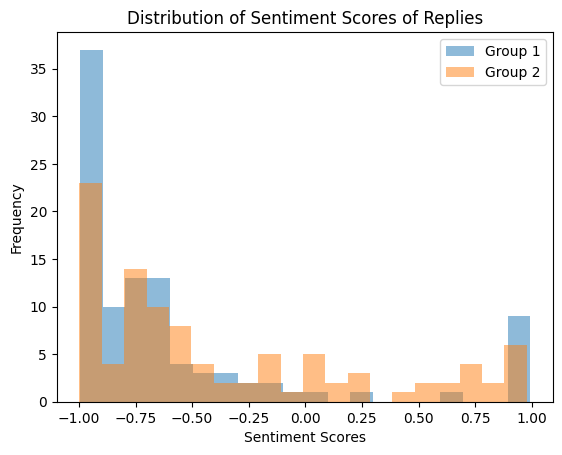

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have two dictionaries: troll_users and normal_users

# Extract sentiment scores for troll users
troll_sentiments = list(troll_users)

# Extract sentiment scores for normal users
normal_sentiments = list(normal_users)

# Plotting
plt.figure()

# Plot histogram for troll users
plt.hist(troll_sentiments, bins=20, alpha=0.5, label='Group 1')

# Plot histogram for normal users
plt.hist(normal_sentiments, bins=20, alpha=0.5, label='Group 2')

# Add labels, title, and legend
plt.xlabel('Sentiment Scores')
plt.ylabel('Frequency')
plt.title('Distribution of Sentiment Scores of Replies')
plt.legend()
plt.savefig(f'/content/drive/MyDrive/sentiment.png', dpi=600)  # Save the chart as a PNG file
plt.show()


In [ ]:
import numpy as np

train_labels_values = list(train_labels.values())
user_scoresx_cleaned = []
train_labels_cleaned = []

for score, label in zip(user_scoresx, train_labels_values):
    if not np.isnan(score).any():
        user_scoresx_cleaned.append(score)
        train_labels_cleaned.append(label)

zipped = list(zip(train_labels_cleaned, user_scoresx_cleaned))

print(zipped)


[(1, array([0.6524184 , 0.34758157], dtype=float32)), (0, array([0.8422947 , 0.15770528], dtype=float32)), (0, array([0.76212096, 0.23787896], dtype=float32)), (0, array([0.59612775, 0.40387222], dtype=float32)), (1, array([0.79128116, 0.20871882], dtype=float32)), (0, array([0.72170603, 0.27829397], dtype=float32)), (0, array([0.58468336, 0.41531673], dtype=float32)), (0, array([0.561179, 0.438821], dtype=float32)), (1, array([0.79370785, 0.20629224], dtype=float32)), (1, array([0.57767457, 0.42232546], dtype=float32)), (0, array([0.4623862 , 0.53761387], dtype=float32)), (0, array([0.6119634 , 0.38803658], dtype=float32)), (0, array([0.44256556, 0.5574345 ], dtype=float32)), (1, array([0.73164546, 0.2683545 ], dtype=float32)), (0, array([0.5738475, 0.4261525], dtype=float32)), (0, array([0.61493087, 0.38506922], dtype=float32)), (0, array([0.6607639 , 0.33923602], dtype=float32)), (1, array([0.39774817, 0.6022519 ], dtype=float32)), (1, array([0.57855415, 0.42144585], dtype=float32))

<ipython-input-221-a3f40fcbb63f>:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('viridis', len(set(labels)))


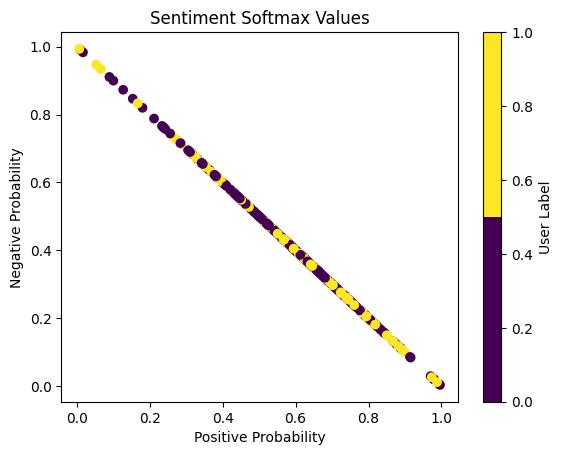

In [ ]:
import matplotlib.pyplot as plt

zipped = list(zip(train_labels_cleaned, user_scoresx_cleaned))

# Separate the sentiment scores and labels
sentiment_scores = [score[1] for score in zipped]
labels = [label[0] for label in zipped]

# Extract positive and negative probabilities from sentiment scores
positive_probs = [score[0] for score in sentiment_scores]
negative_probs = [score[1] for score in sentiment_scores]

# Create a colormap for the labels
colormap = plt.cm.get_cmap('viridis', len(set(labels)))

# Plot the sentiment softmax values
plt.scatter(positive_probs, negative_probs, c=labels, cmap=colormap)

# Set labels and title
plt.xlabel('Positive Probability')
plt.ylabel('Negative Probability')
plt.title('Sentiment Softmax Values')

# Create a colorbar for the labels
cbar = plt.colorbar()
cbar.set_label('User Label')

# Show the plot
plt.show()


In [ ]:
import json

# Save the zipped list as JSON
with open('reply_sentiment_scores_train_.json', 'w') as file:
    json.dump(list(zip(train_labels_cleaned, user_scoresx_cleaned)), file)


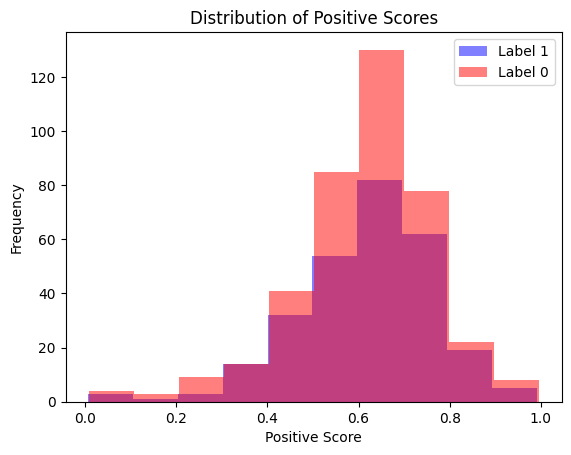

In [ ]:
import matplotlib.pyplot as plt

positive_scores = [score[0] for score in user_scoresx_cleaned]

positive_scores_label1 = [score for i, score in enumerate(positive_scores) if train_labels_cleaned[i] == 1]
positive_scores_label0 = [score for i, score in enumerate(positive_scores) if train_labels_cleaned[i] == 0]

plt.hist(positive_scores_label1, bins=10, color='blue', alpha=0.5, label='Label 1')
plt.hist(positive_scores_label0, bins=10, color='red', alpha=0.5, label='Label 0')

plt.xlabel('Positive Score')
plt.ylabel('Frequency')
plt.title('Distribution of Positive Scores')
plt.legend()

plt.show()


# Image Features

In [ ]:
import json
path_to_profile_pic_features = f"{HOME_PATH}/pp_features.json"
path_to_banner_features = f"{HOME_PATH}/banner_features.json"

with open(path_to_profile_pic_features, "r") as file:
  profile_pic_features = json.load(file)

with open(path_to_banner_features, "r") as file:
  banner_features = json.load(file)


In [ ]:
profile_pic_features_length = len(profile_pic_features['1004046890596528129'])
banner_features_length = len(banner_features['101056690'])
image_features = {}
for key in list(train_labels.keys()) + list(val_labels.keys()):
  if key not in profile_pic_features:
    profile_pic_features[key] = [0] * profile_pic_features_length
  if key not in banner_features:
    banner_features[key] = [0] * banner_features_length
  image_features[key] = profile_pic_features[key] + banner_features[key]

In [ ]:
for k, v in image_user_val.items():
  if len(v['features']) != 47:
    print(k)

0
1


In [ ]:
image_user_train = {k:{"features":v, "label": train_labels[k]} for k,v in image_features.items() if k in train_labels}
image_user_val = {k:{"features":v, "label": val_labels[k]} for k,v in image_features.items() if k in val_labels}

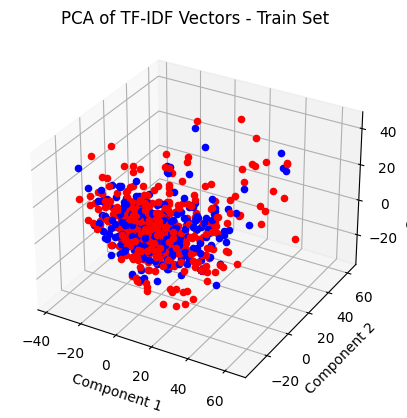

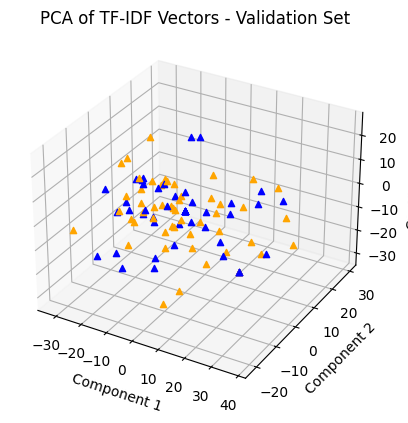

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA


# Apply PCA to reduce the dimensionality of the TF-IDF vectors to 3
image_user_train_vectors = [value['features'] for value in image_user_train.values()]
image_user_val_vectors = [value['features'] for value in image_user_val.values()]

image_user_train_labels = [value['label'] for value in image_user_train.values()]
image_user_val_labels = [value['label'] for value in image_user_val.values()]

pca = PCA(n_components=3)
pca_vectors_train = pca.fit_transform(image_user_train_vectors)
pca_vectors_val = pca.transform(image_user_val_vectors)

# Create a 3D scatter plot for the train set
fig_train = plt.figure()
ax_train = fig_train.add_subplot(111, projection='3d')

# Scatter plot of the PCA vectors of the train set colored by train labels
for i, label in enumerate(image_user_train_labels):
    color = 'blue' if label == 0 else 'red'
    ax_train.scatter(pca_vectors_train[i, 0], pca_vectors_train[i, 1], pca_vectors_train[i, 2], c=color, marker='o')

# Set labels and title for train plot
ax_train.set_xlabel('Component 1')
ax_train.set_ylabel('Component 2')
ax_train.set_zlabel('Component 3')
ax_train.set_title('PCA of TF-IDF Vectors - Train Set')

# Show the train plot
plt.show()

# Create a 3D scatter plot for the validation set
fig_val = plt.figure()
ax_val = fig_val.add_subplot(111, projection='3d')

# Scatter plot of the PCA vectors of the validation set colored by validation labels
for i, label in enumerate(image_user_val_labels):
    color = 'blue' if label == 0 else 'orange'
    ax_val.scatter(pca_vectors_val[i, 0], pca_vectors_val[i, 1], pca_vectors_val[i, 2], c=color, marker='^')

# Set labels and title for validation plot
ax_val.set_xlabel('Component 1')
ax_val.set_ylabel('Component 2')
ax_val.set_zlabel('Component 3')
ax_val.set_title('PCA of TF-IDF Vectors - Validation Set')

# Show the validation plot
plt.show()

In [ ]:
import joblib

# Save the ensemble model
#joblib.dump(ensemble, f'{HOME_PATH}/ensemble_model.pkl')

['/content/drive/MyDrive/ensemble_model.pkl']

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Create individual classifiers
svm = SVC(C=1, kernel='rbf', gamma=1)
rf = RandomForestClassifier(n_estimators=100)
nn = MLPClassifier(hidden_layer_sizes=(100,))

# Create an ensemble using VotingClassifier
ensemble = VotingClassifier(
    estimators=[
        ('svm', svm),
        ('random_forest', rf),
        ('neural_network', nn)
    ],
    voting='hard'  # Use majority voting for classification
)

# Train the ensemble on the training data
ensemble.fit(train_tfidf_vectors.toarray(), train_labels)

# Make predictions on the validation data
ensemble_predictions = ensemble.predict(val_tfidf_vectors.toarray())

# Evaluate the accuracy of the ensemble
ensemble_accuracy = accuracy_score(val_labels, ensemble_predictions)

print("Ensemble Accuracy:", ensemble_accuracy)


ValueError: ignored

In [ ]:
for i,(k,v) in enumerate(tfidf_user_val.items()):
  if ensemble_predictions[i] != v['label']:
    print(i, k,f"True label {v['label']}", f"Prediction {ensemble_predictions[i]}", account_id_screen_name[k])

11 912160682 True label 0 Prediction 1 SAMUELMILLERJR
32 994220556814880768 True label 0 Prediction 1 ta2ixv
50 1308454163513315343 True label 0 Prediction 1 sorgusuzhakim
53 1332675495801008128 True label 0 Prediction 1 AbdurrahmanDnc1
59 1394066038829035522 True label 0 Prediction 1 Belgin73721646
60 1397067952206327809 True label 0 Prediction 1 DOAN19047474
88 1577584872780087296 True label 1 Prediction 0 ahmetacikli


# TF-IDF

## TF-IDF Vectorization

In [ ]:
tfidf_user_train = {k:{"text":v, "label": train_labels[k]} for k,v in users_pp_documents.items() if k in train_labels}
tfidf_user_val = {k:{"text":v, "label": val_labels[k]} for k,v in users_pp_documents.items() if k in val_labels}
tfidf_user_test = {k:{"text":v, "label": test_labels[k]} for k,v in users_pp_documents.items() if k in test_labels}

In [ ]:
tfidf_user_train['1177970967680835584']

{'text': 'soylu gereken açıklamayı yetmedi galiba yakında ayrı açıklama gelir korkma sınırımızda ypg olacak diyenlere laf yokmu geri sırtını ypg pkk dayayanlara soyle birde suriyede sinir komşumuz ypg diyen kemale soyle armut demek beraber mada görüşmeleri amerika ingiltere ziyaretleri valla yazık kimsiniz medet umuyor hizmet ediyorsunuz yazik ulan açıklamayı yapan yalan haber yasaklanıyor koyunsunuz yazik kanini baktirsana ka siniz kanınız boz patlama gelen bakan kimlerin açıklayan şerefsiz bombacı gondereni bulan yazık saysana hadi bakalim baska ülkede karar alındığı zaman demokrasi ay güzel ülkende zaman özgürlük kısıtlanamaz hadi canim yanlı ülkeden uzak birisiniz belli ayakkabı numarası nerene dokundu ülkede çekilen açıdan medet uman kişilere aciyorum valla insan olmamak terörden medet ummak birsey galiba yazık yüzüne tükursen yağmur der yazik sap samani karıştırıyorsun bal chp hdpkk görüştüğü nu biliyorsun isiniz laf cambazligi aç tavuk ambar chp zaman 30 aldı bırakın ayakları ko

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score

# Collect the user texts and labels from the tfidf_user_train dictionary
train_extra_features = []
train_texts = []
train_labels = []
for user_id, user_data in tfidf_user_train.items():
    train_texts.append(user_data['text'])
    train_labels.append(user_data['label'])
    train_extra_features.append(extra_features[user_id])

# Collect the user texts and labels from the tfidf_user_val dictionary
val_extra_features = []
val_texts = []
val_labels = []
for user_id, user_data in tfidf_user_val.items():
    val_texts.append(user_data['text'])
    val_labels.append(user_data['label'])
    val_extra_features.append(extra_features[user_id])

# Collect the user texts and labels from the tfidf_user_test dictionary
test_extra_features = []
test_texts = []
test_labels = []
for user_id, user_data in tfidf_user_test.items():
    test_texts.append(user_data['text'])
    test_labels.append(user_data['label'])
    test_extra_features.append(extra_features[user_id])

# Create an instance of TfidfVectorizer for the training set
vectorizer_train = TfidfVectorizer(norm='l2')
tfidf_vectors_train = vectorizer_train.fit_transform(train_texts)
train_tfidf_vectors = tfidf_vectors_train

# Transform the val set texts into TF-IDF vectors using the trained vectorizer
tfidf_vectors_val = vectorizer_train.transform(val_texts)
val_tfidf_vectors = tfidf_vectors_val

# Transform the test set texts into TF-IDF vectors using the trained vectorizer
tfidf_vectors_test = vectorizer_train.transform(test_texts)
test_tfidf_vectors = tfidf_vectors_test

### Ground Truth Labels

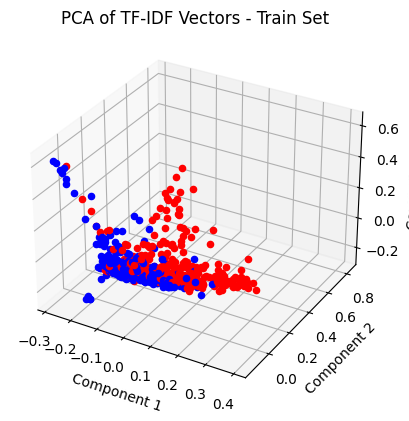

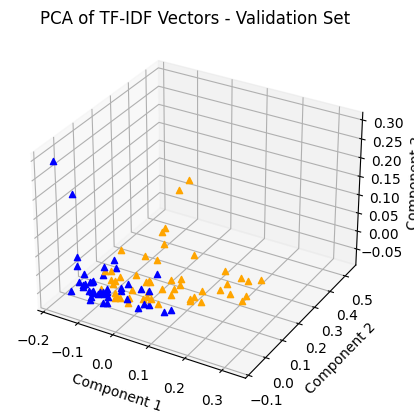

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Apply PCA to reduce the dimensionality of the TF-IDF vectors to 3
pca = PCA(n_components=3)
pca_vectors_train = pca.fit_transform(tfidf_vectors_train.toarray())
pca_vectors_val = pca.transform(tfidf_vectors_val.toarray())

# Create a 3D scatter plot for the train set
fig_train = plt.figure()
ax_train = fig_train.add_subplot(111, projection='3d')

# Scatter plot of the PCA vectors of the train set colored by train labels
for i, label in enumerate(train_labels):
    color = 'blue' if label == 0 else 'red'
    ax_train.scatter(pca_vectors_train[i, 0], pca_vectors_train[i, 1], pca_vectors_train[i, 2], c=color, marker='o')

# Set labels and title for train plot
ax_train.set_xlabel('Component 1')
ax_train.set_ylabel('Component 2')
ax_train.set_zlabel('Component 3')
ax_train.set_title('PCA of TF-IDF Vectors - Train Set')
#plt.savefig(f'{HOME_PATH}/tfidf_pca_train.png', dpi=600)  # Save the chart as a PNG file

# Show the train plot
plt.show()

# Create a 3D scatter plot for the validation set
fig_val = plt.figure()
ax_val = fig_val.add_subplot(111, projection='3d')

# Scatter plot of the PCA vectors of the validation set colored by validation labels
for i, label in enumerate(val_labels):
    color = 'blue' if label == 0 else 'orange'
    ax_val.scatter(pca_vectors_val[i, 0], pca_vectors_val[i, 1], pca_vectors_val[i, 2], c=color, marker='^')

# Set labels and title for validation plot
ax_val.set_xlabel('Component 1')
ax_val.set_ylabel('Component 2')
ax_val.set_zlabel('Component 3')
ax_val.set_title('PCA of TF-IDF Vectors - Validation Set')
#plt.savefig(f'{HOME_PATH}/tfidf_pca_val.png', dpi=600)  # Save the chart as a PNG file

# Show the validation plot
plt.show()


### Metrics

In [ ]:
pca_draw = PCA(n_components=3)
pca_draw_vectors_train = pca_draw.fit_transform(train_tfidf_vectors.toarray())
pca_draw_vectors_val = pca_draw.transform(val_tfidf_vectors.toarray())
pca_draw_vectors_test = pca_draw.transform(test_tfidf_vectors.toarray())

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

HOME_PATH = "/content/drive/MyDrive"
# Assuming you have the true labels (y_true) and predicted labels (y_pred)
def create_confusion_matrix(y_true, y_pred, set_name="", model_name = ". . - -"):
  path = HOME_PATH + "/model_results"
  # Calculate accuracy, precision, recall, and F1-score
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)

  # Create a confusion matrix
  cm = confusion_matrix(y_true, y_pred)
  # Calculate the values for each cell as percentages
  cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

  # Plot the confusion matrix with labeled percentages
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues")
  plt.title(f"Confusion Matrix {set_name}")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.xticks([0.5, 1.5], ["Class 0", "Class 1"])
  plt.yticks([0.5, 1.5], ["Class 0", "Class 1"])
  plt.savefig(f'{path}/{model_name}_{set_name}_confusion_matrix.png', dpi=600)  # Save the chart as a PNG file
  plt.show()

  # Create a square plot for F1-score and accuracy
  plt.figure(figsize=(8, 4))
  # Accuracy square
  plt.fill([0, 1, 1, 0], [0, 0, accuracy, accuracy], color='royalblue')
  plt.text(0.5, accuracy / 2, f"{accuracy:.2f}%", ha="center", va="center", color="black", fontsize=12)
  # F1-score square
  plt.fill([1, 2, 2, 1], [0, 0, f1, f1], color='aquamarine')
  plt.text(1.5, f1 / 2, f"{f1:.2f}%", ha="center", va="center", color="black", fontsize=12)
  plt.title(f"Model Evaluation {set_name}", y=1.05)
  plt.xlim(0, 2)
  plt.ylim(0, 1)
  plt.xticks([0.5, 1.5], ["Accuracy", "F1-score"])
  plt.yticks([])
  plt.xlabel("Metric")
  plt.ylabel("Score")
  plt.savefig(f"{path}/{model_name}_{set_name}_model_evaluation.png", dpi=600)  # Save the chart as a PNG file
  plt.show()

  fig_train = plt.figure()
  ax_train = fig_train.add_subplot(111, projection='3d')

  pca_vectors = None
  if set_name == 'Validation Set':
    pca_vectors = pca_draw_vectors_val
  elif set_name == "Train Set":
    pca_vectors = pca_draw_vectors_train
  elif set_name == "Test Set":
    pca_vectors = pca_draw_vectors_test

  # Scatter plot of the first 3 components of the PCA vectors of the train set colored by cluster labels
  for i, cluster_label in enumerate(y_pred):
      color = 'blue' if cluster_label == 0 else 'red'
      ax_train.scatter(pca_vectors[i, 0], pca_vectors[i, 1], pca_vectors[i, 2], c=color)

  # Set labels and title for train plot
  ax_train.set_xlabel('Component 1')
  ax_train.set_ylabel('Component 2')
  ax_train.set_zlabel('Component 3')
  ax_train.set_title(f'Classification {set_name}')

  print("Accuracy: ", accuracy)
  print("Precision: ", precision)
  print("Recall: ", recall)
  print("F1: ", f1)

  # Save the 3D scatter plot for the set
  plt.savefig(f'{path}/{model_name}_{set_name}_classification.png', dpi=600)  # Save the chart as a PNG file
  # Show the train plot
  plt.show()

### Training Preperation

In [ ]:
NUM_COMPONENTS = 30
train_labels = []
for user_id, user_data in tfidf_user_train.items():
    train_labels.append(user_data['label'])

val_labels = []
for user_id, user_data in tfidf_user_val.items():
    val_labels.append(user_data['label'])

test_labels = []
for user_id, user_data in tfidf_user_test.items():
    test_labels.append(user_data['label'])

# Apply PCA to reduce the dimensionality of the TF-IDF vectors to 20
pca = PCA(n_components=NUM_COMPONENTS)
pca_vectors_train = pca.fit_transform(train_tfidf_vectors.toarray())
pca_vectors_val = pca.transform(val_tfidf_vectors.toarray())
pca_vectors_test = pca.transform(test_tfidf_vectors.toarray())

## Clustering Over TF-IDF

### Spectral Clustering

Confusion Matrix - Test Set:


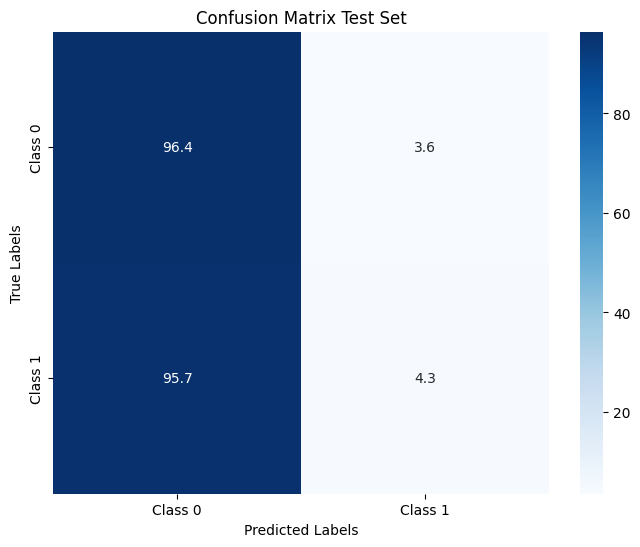

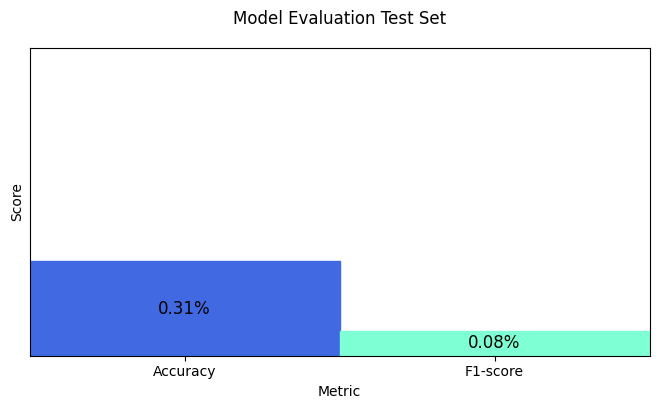

Accuracy:  0.30612244897959184
Precision:  0.75
Recall:  0.04285714285714286
F1:  0.08108108108108107


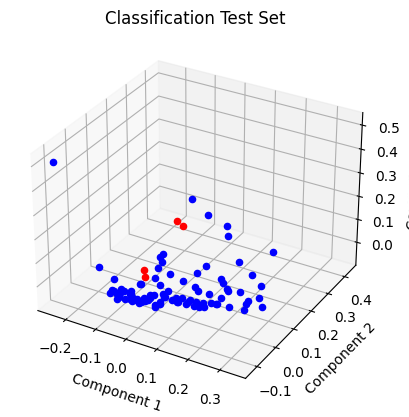

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.metrics import accuracy_score


model_name = "spectral_clustering"

# Perform spectral clustering on the PCA vectors of the train set
spectral_clustering = SpectralClustering(n_clusters=2)

cluster_labels_train = spectral_clustering.fit_predict(pca_vectors_train)
cluster_labels_val = spectral_clustering.fit_predict(pca_vectors_val)
cluster_labels_test = spectral_clustering.fit_predict(pca_vectors_test)


# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, cluster_labels_test, "Test Set", model_name=model_name)

### DB-SCAN

Confusion Matrix - Test Set:


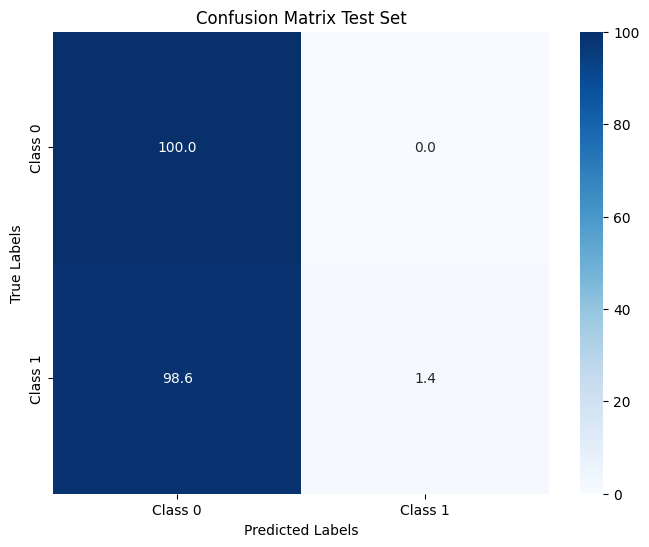

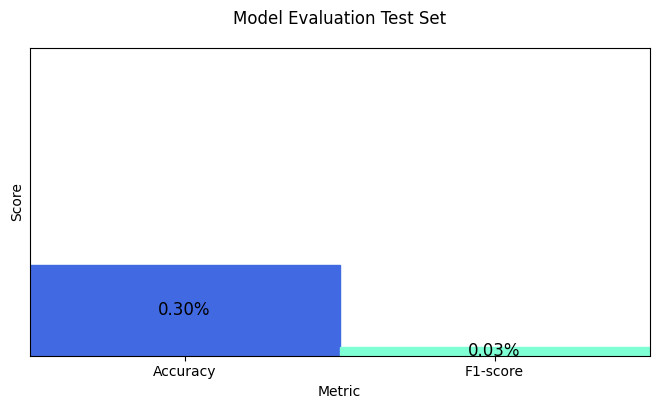

Accuracy:  0.29591836734693877
Precision:  1.0
Recall:  0.014285714285714285
F1:  0.028169014084507043


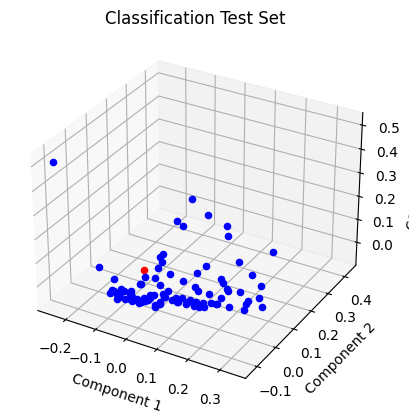

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import accuracy_score

model_name = "dbscan"

# Perform DBSCAN clustering on the PCA vectors of the train set
dbscan = DBSCAN(eps=0.5, min_samples=5)
cluster_labels_train = dbscan.fit_predict(pca_vectors_train)

# Perform DBSCAN clustering on the PCA vectors of the test set
cluster_labels_val = dbscan.fit_predict(pca_vectors_val)
cluster_labels_test = dbscan.fit_predict(pca_vectors_test)


cluster_labels_val = [1 if label == -1 else label for label in cluster_labels_val]
cluster_labels_train = [1 if label == -1 else label for label in cluster_labels_train]
cluster_labels_test = [1 if label == -1 else label for label in cluster_labels_test]


# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, cluster_labels_test, "Test Set", model_name=model_name)


### Gaussian Mixture Model

Confusion Matrix - Test Set:


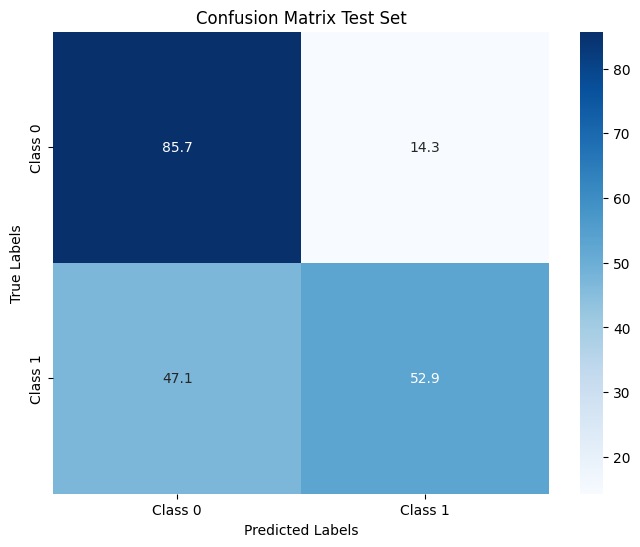

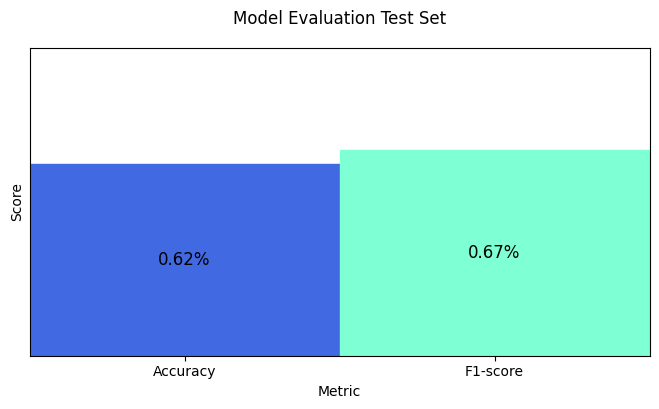

Accuracy:  0.6224489795918368
Precision:  0.9024390243902439
Recall:  0.5285714285714286
F1:  0.6666666666666666


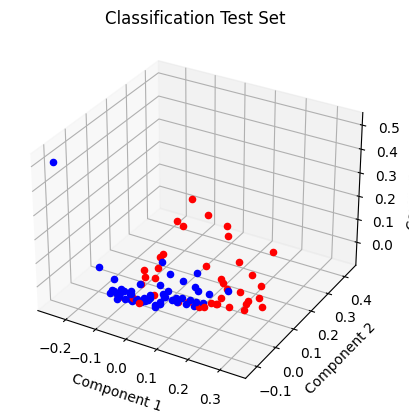

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

model_name = "gaussian_mixture"

# Perform Gaussian Mixture Model on the PCA vectors of the train set
gmm = GaussianMixture(n_components=2)

cluster_labels_train = gmm.fit_predict(pca_vectors_train)
cluster_labels_val = gmm.predict(pca_vectors_val)
cluster_labels_test = gmm.predict(pca_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, cluster_labels_test, "Test Set", model_name=model_name)

### Agglomerative Clustering

Confusion Matrix - Test Set:


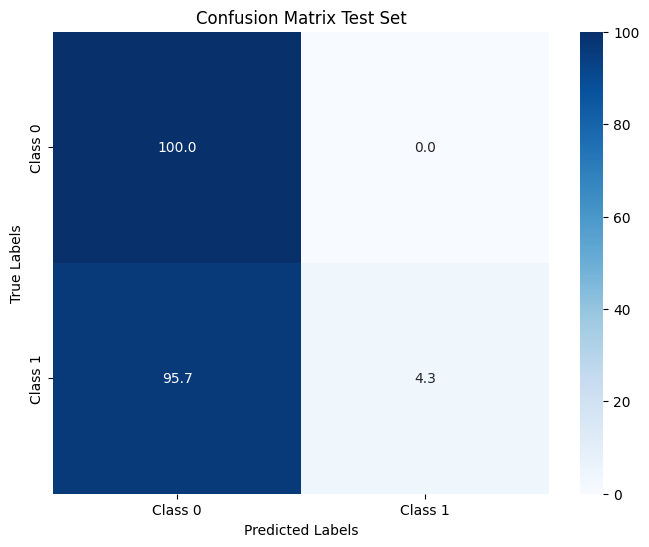

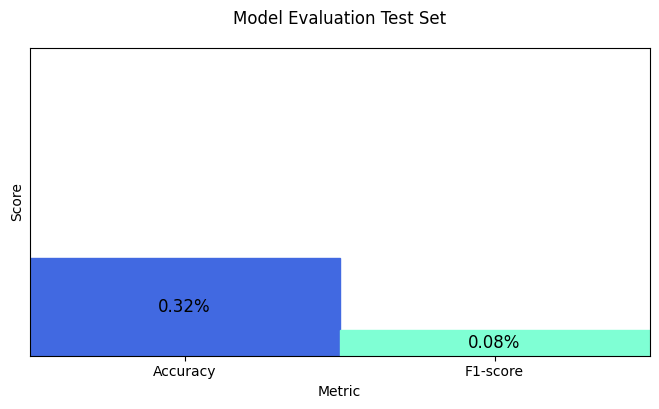

Accuracy:  0.3163265306122449
Precision:  1.0
Recall:  0.04285714285714286
F1:  0.0821917808219178


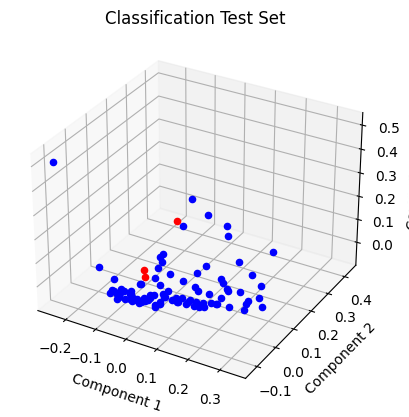

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score


model_name = "agglomerative_clustering"

# Perform agglomerative clustering on the PCA vectors of the train set
agglomerative_clustering = AgglomerativeClustering(n_clusters=2)

cluster_labels_train = agglomerative_clustering.fit_predict(pca_vectors_train)
cluster_labels_val = agglomerative_clustering.fit_predict(pca_vectors_val)
cluster_labels_test = agglomerative_clustering.fit_predict(pca_vectors_test)


# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, cluster_labels_test, "Test Set", model_name=model_name)

## Supervised Algorithms

### Logistic Regression

Confusion Matrix - Test Set:


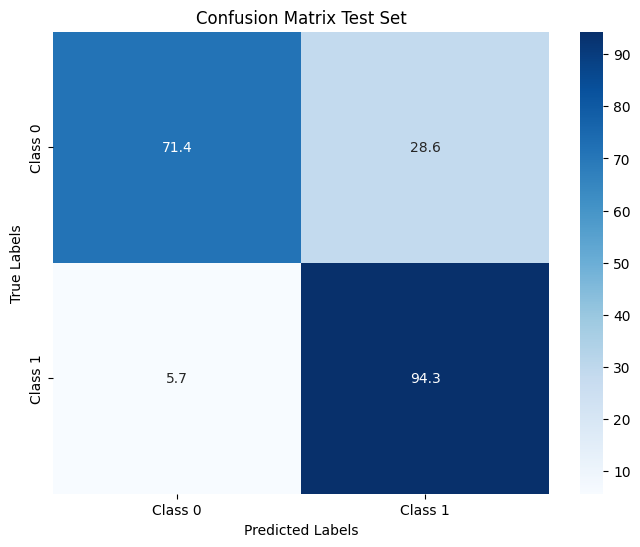

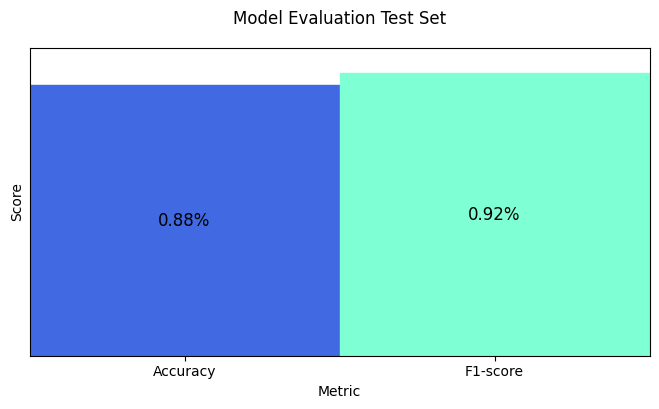

Accuracy:  0.8775510204081632
Precision:  0.8918918918918919
Recall:  0.9428571428571428
F1:  0.9166666666666667


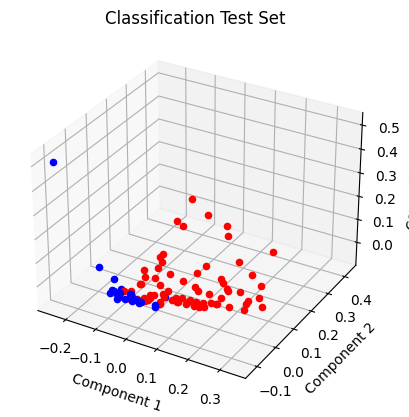

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_name = "logistic_regression"

# Initialize and train the logistic regression model
logistic_regression = LogisticRegression()
logistic_regression.fit(pca_vectors_train, train_labels)

# Predict the labels for the train and validation sets
predicted_labels_train = logistic_regression.predict(pca_vectors_train)
predicted_labels_val = logistic_regression.predict(pca_vectors_val)
predicted_labels_test = logistic_regression.predict(pca_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)

### Naive Bayes

Confusion Matrix - Test Set:


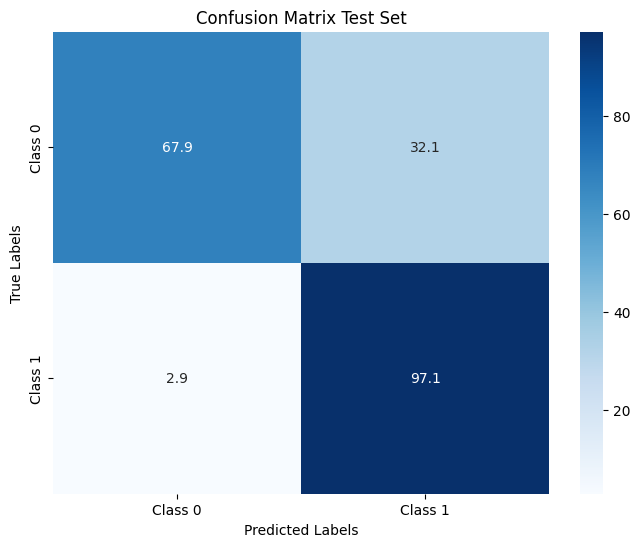

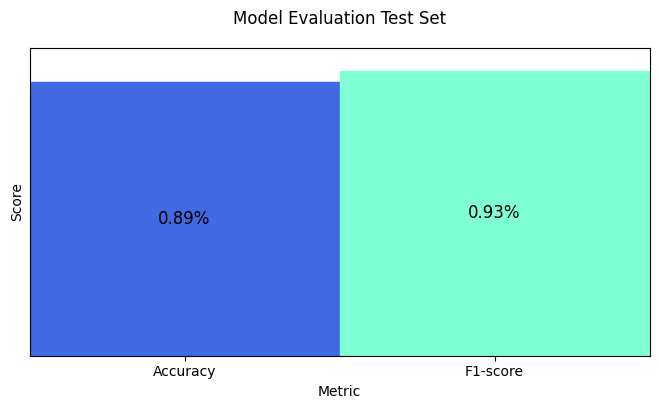

Accuracy:  0.8877551020408163
Precision:  0.8831168831168831
Recall:  0.9714285714285714
F1:  0.9251700680272108


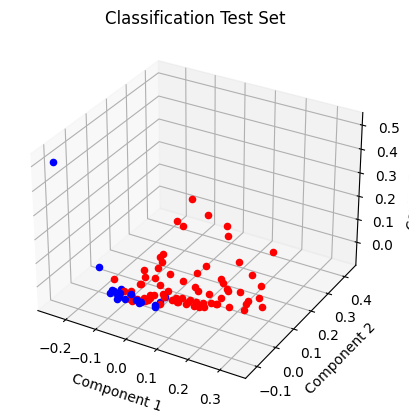

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model_name = "naive_bayes"

# Train the Naive Bayes classifier
naive_bayes = GaussianNB()
naive_bayes.fit(pca_vectors_train, train_labels)

# Predict labels for the validation set
pred_labels_val = naive_bayes.predict(pca_vectors_val)
pred_labels_test = naive_bayes.predict(pca_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, pred_labels_test, "Test Set", model_name=model_name)

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model_name = "knn"

# Train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(pca_vectors_train, train_labels)

# Predict labels for the validation set
pred_labels_test = knn.predict(pca_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, pred_labels_test, "Test Set", model_name=model_name)

TypeError: ignored

### SVM

Confusion Matrix - Test Set:


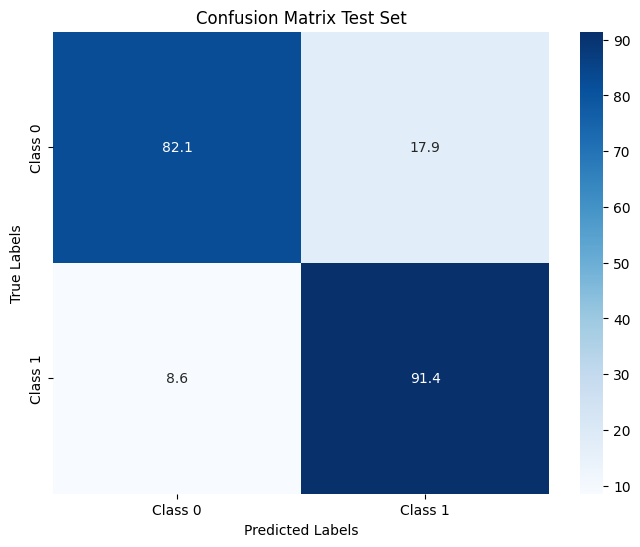

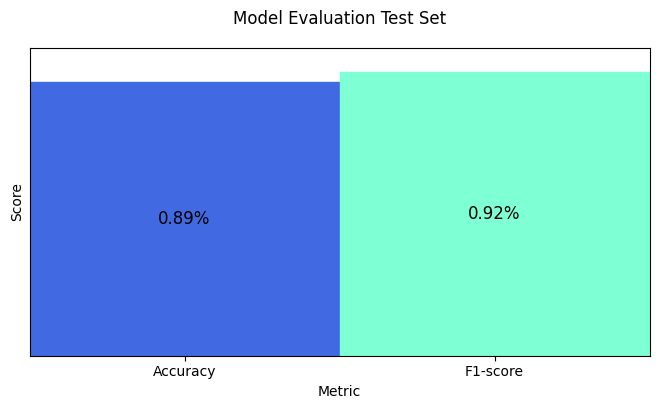

Accuracy:  0.8877551020408163
Precision:  0.927536231884058
Recall:  0.9142857142857143
F1:  0.920863309352518


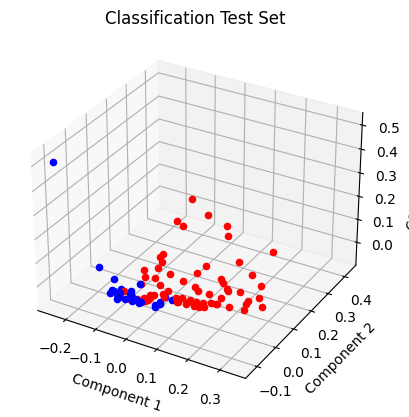

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_name = "svm"

# Initialize and train the SVM classifier
svm = SVC()
svm.fit(pca_vectors_train, train_labels)

# Predict the labels for the train and validation sets
predicted_labels_train = svm.predict(pca_vectors_train)
predicted_labels_test = svm.predict(pca_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)

In [ ]:
import joblib

# Load the SVM model from the joblib file
svm_model = joblib.load(f'{HOME_PATH}/best_model.pkl')


In [ ]:
"""
# Predict the labels for the train and validation sets
predicted_labels_train = svm_model.predict(pca_vectors_train)
predicted_labels_test = svm_model.predict(pca_vectors_test)
model_name="svm"
# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)

"""

'\n# Predict the labels for the train and validation sets\npredicted_labels_train = svm_model.predict(pca_vectors_train)\npredicted_labels_test = svm_model.predict(pca_vectors_test)\nmodel_name="svm"\n# Print the confusion matrix for the validation set\nprint("Confusion Matrix - Test Set:")\ncreate_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)\n\n'

Confusion Matrix - Validation Set (Best Model):
Best Params:  Parameters: C=1, kernel=linear, gamma=scale, n_components=30


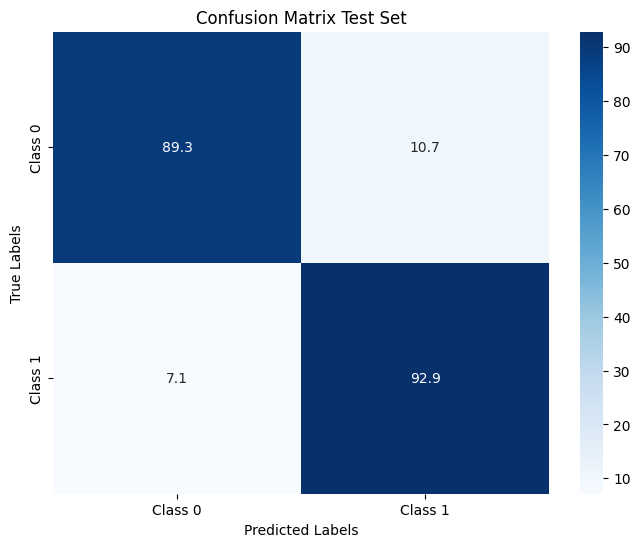

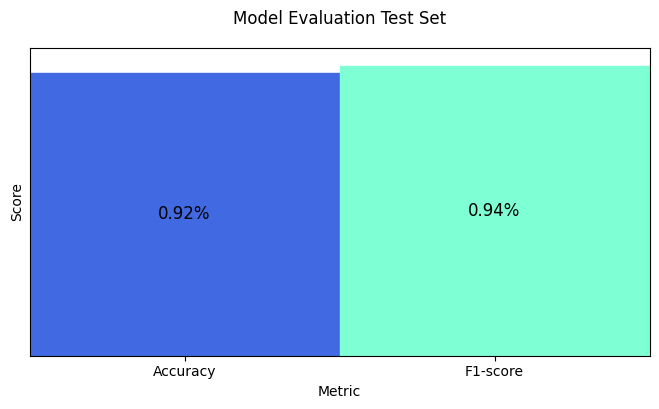

Accuracy:  0.9183673469387755
Precision:  0.9558823529411765
Recall:  0.9285714285714286
F1:  0.9420289855072465


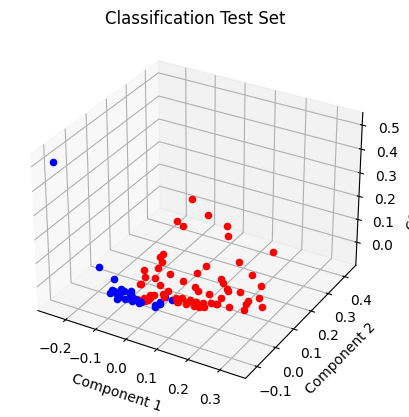

Best model saved as 'best_model.pkl'


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from itertools import product

model_name = "svm_best"

# Define parameter grid for tuning
param_grid = {'C': [0.1, 1, 10],
              'kernel': ['linear', 'rbf', 'poly'],
              'gamma': ['scale', 'auto'],
              'n_components': [30, 100, 250, 500]}

best_f1_score = 0.0
best_model = None

# Iterate over parameter combinations
for n_components in param_grid['n_components']:
  # Apply PCA to reduce the dimensionality of the TF-IDF vectors
  pca = PCA(n_components=n_components)
  pca_vectors_train = pca.fit_transform(train_tfidf_vectors.toarray())
  pca_vectors_val = pca.transform(val_tfidf_vectors.toarray())
  for C, kernel, gamma in product(param_grid['C'], param_grid['kernel'], param_grid['gamma']):
    # Initialize and train the SVM classifier
    svm = SVC(C=C, kernel=kernel, gamma=gamma)
    svm.fit(pca_vectors_train, train_labels)

    # Predict the labels for the validation set
    predicted_labels_val = svm.predict(pca_vectors_val)

    # Calculate F1 score
    f1 = f1_score(val_labels, predicted_labels_val)

    # Check if current model has the best F1 score so far
    if f1 > best_f1_score:
        best_f1_score = f1
        best_model = svm
        best_pca = pca
        best_params = f"Parameters: C={C}, kernel={kernel}, gamma={gamma}, n_components={n_components}"

# Print the confusion matrix for the validation set using the best model
print("Confusion Matrix - Validation Set (Best Model):")
print("Best Params: ", best_params)
pca_vectors_val_best = best_pca.transform(val_tfidf_vectors.toarray())
pca_vectors_test_best = best_pca.transform(test_tfidf_vectors.toarray())

predicted_labels_test_best = best_model.predict(pca_vectors_test_best)
create_confusion_matrix(test_labels, predicted_labels_test_best, "Test Set", model_name=model_name)

# Save the best model
joblib.dump(best_model, f'{HOME_PATH}/best_model.pkl')
print("Best model saved as 'best_model.pkl'")

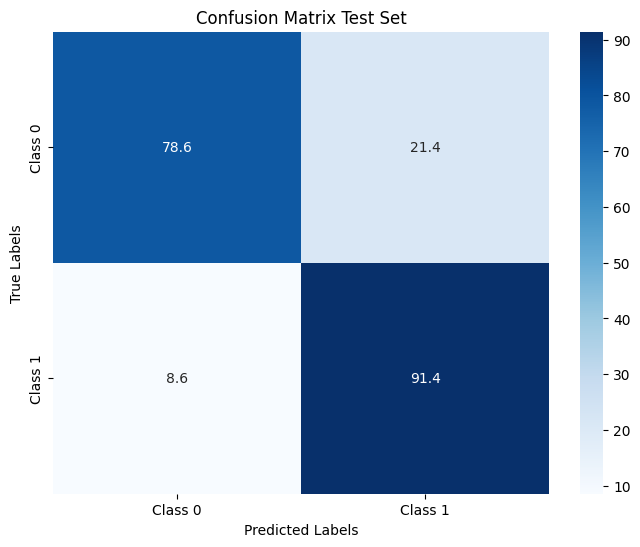

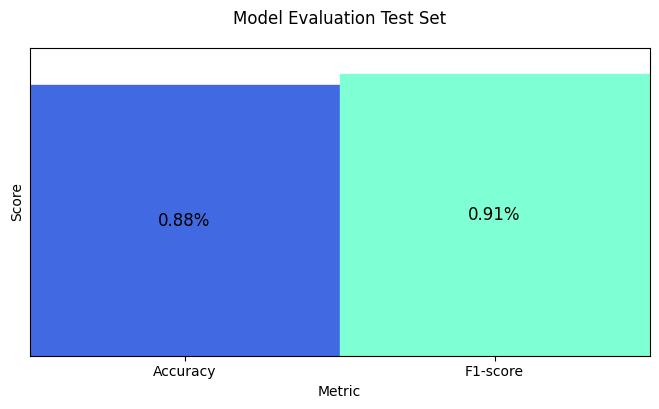

Accuracy:  0.8775510204081632
Precision:  0.9142857142857143
Recall:  0.9142857142857143
F1:  0.9142857142857143


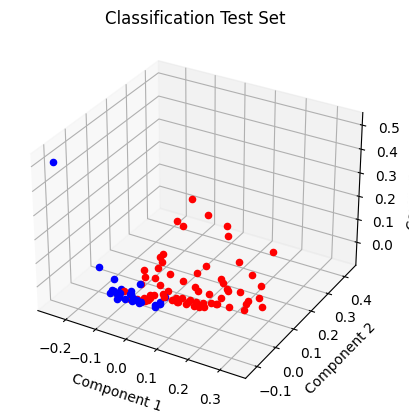

'\nfor i,(k,v) in enumerate(tfidf_user_test.items()):\n  if predicted_labels_test_best[i] != v[\'label\']:\n    print(i, k,f"True label {v[\'label\']}", f"Prediction {predicted_labels_test_best[i]}", account_id_screen_name[k])\n'

In [ ]:
pca = PCA(n_components=30)
pca_vectors_train = pca.fit_transform(train_tfidf_vectors.toarray())
pca_vectors_test = pca.transform(test_tfidf_vectors.toarray())

predicted_labels_test_best = best_model.predict(pca_vectors_test)
create_confusion_matrix(test_labels, predicted_labels_test_best, "Test Set", model_name="svm_best")
"""
for i,(k,v) in enumerate(tfidf_user_test.items()):
  if predicted_labels_test_best[i] != v['label']:
    print(i, k,f"True label {v['label']}", f"Prediction {predicted_labels_test_best[i]}", account_id_screen_name[k])
"""

### Random Forests

Confusion Matrix - Test Set:


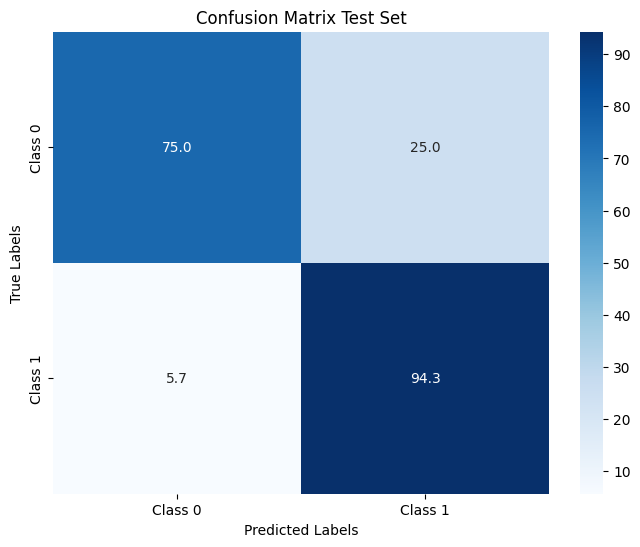

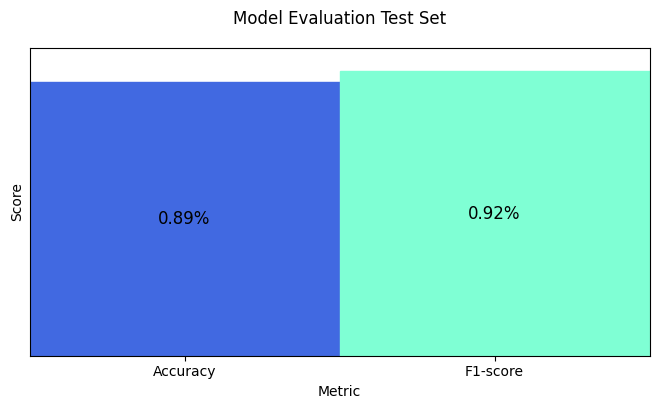

Accuracy:  0.8877551020408163
Precision:  0.9041095890410958
Recall:  0.9428571428571428
F1:  0.923076923076923


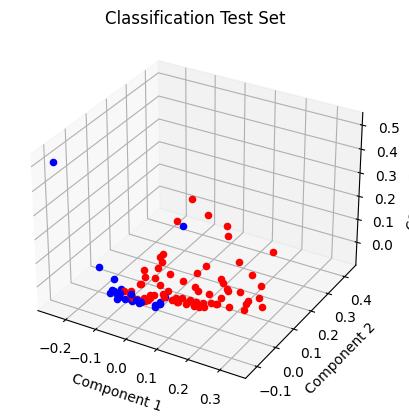

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model_name = "random_forests"

# Initialize and train the Random Forest classifier
random_forest = RandomForestClassifier()
random_forest.fit(pca_vectors_train, train_labels)

# Predict the labels for the train and validation sets
predicted_labels_train = random_forest.predict(pca_vectors_train)
predicted_labels_val = random_forest.predict(pca_vectors_val)
predicted_labels_test = random_forest.predict(pca_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)

### Linear Discriminant Analysis

Confusion Matrix - Test Set:


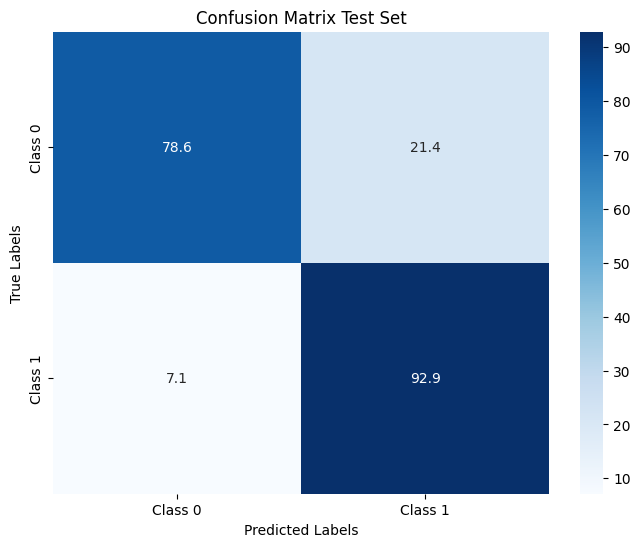

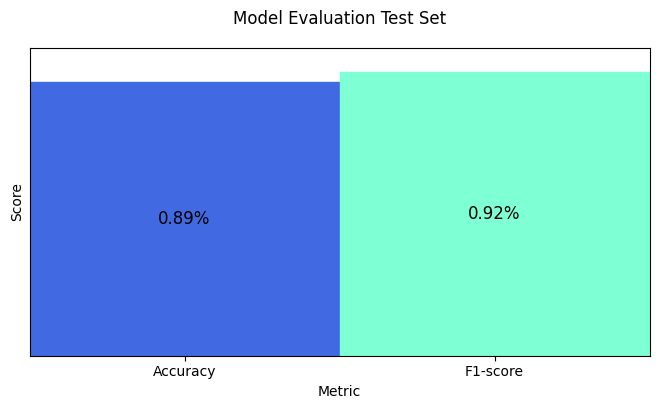

Accuracy:  0.8877551020408163
Precision:  0.9154929577464789
Recall:  0.9285714285714286
F1:  0.921985815602837


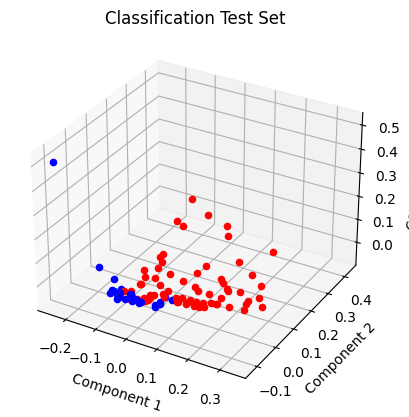

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model_name = "linear_discriminant_analysis"

# Apply Linear Discriminant Analysis (LDA) to the PCA vectors
lda = LinearDiscriminantAnalysis()
lda_vectors_train = lda.fit_transform(pca_vectors_train, train_labels)
lda_vectors_val = lda.transform(pca_vectors_val)
lda_vectors_test = lda.transform(pca_vectors_test)


# Initialize and train the LDA classifier
lda_classifier = LinearDiscriminantAnalysis()
lda_classifier.fit(lda_vectors_train, train_labels)

# Predict the labels for the train and validation sets
predicted_labels_train = lda_classifier.predict(lda_vectors_train)
predicted_labels_val = lda_classifier.predict(lda_vectors_val)
predicted_labels_test = lda_classifier.predict(lda_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)

### Quadratic Discriminant Analysis

Confusion Matrix - Test Set:


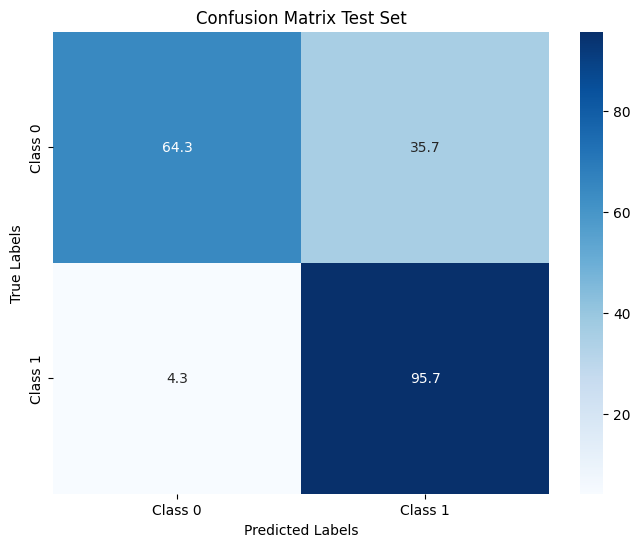

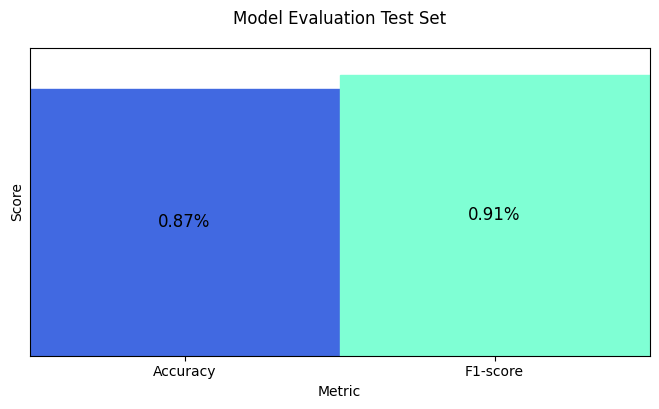

Accuracy:  0.8673469387755102
Precision:  0.8701298701298701
Recall:  0.9571428571428572
F1:  0.9115646258503401


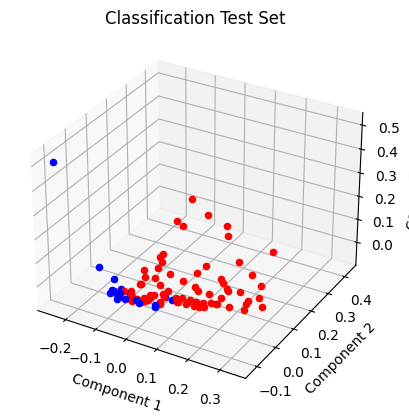

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model_name = "quadratic_discriminant_analysis"

# Apply Quadratic Discriminant Analysis (QDA) to the PCA vectors
qda = QuadraticDiscriminantAnalysis()
qda.fit(pca_vectors_train, train_labels)
predicted_labels_train = qda.predict(pca_vectors_train)
predicted_labels_val = qda.predict(pca_vectors_val)
predicted_labels_test = qda.predict(pca_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)

### Gradient Boosting

Confusion Matrix - Test Set:


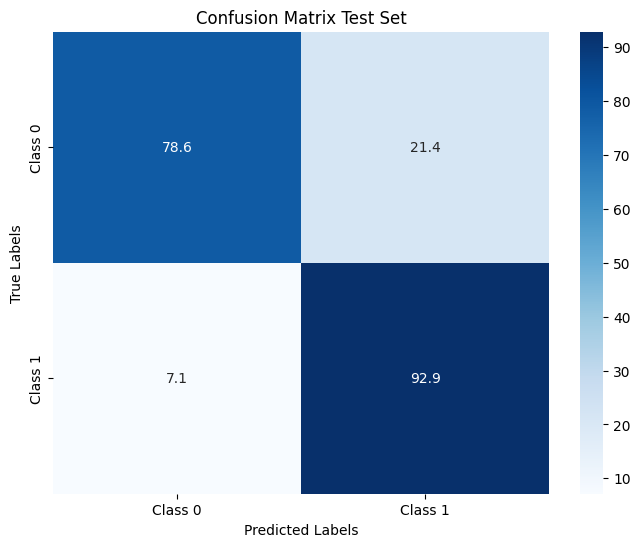

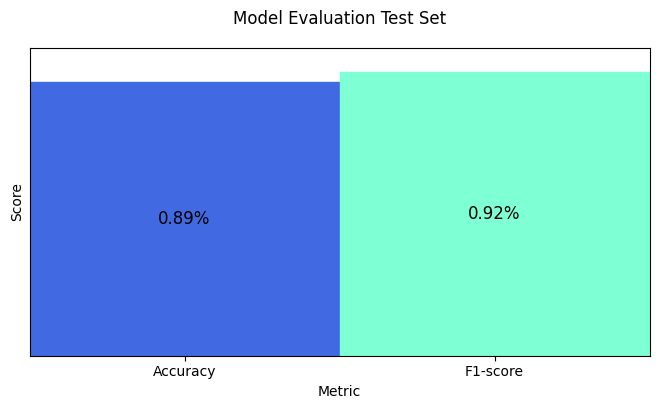

Accuracy:  0.8877551020408163
Precision:  0.9154929577464789
Recall:  0.9285714285714286
F1:  0.921985815602837


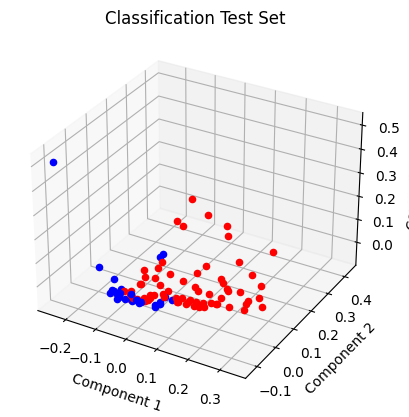

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model_name = "gradient_boosting"

# Initialize and train the Gradient Boosting classifier
gradient_boosting = GradientBoostingClassifier()
gradient_boosting.fit(pca_vectors_train, train_labels)

# Predict the labels for the train and validation sets
predicted_labels_train = gradient_boosting.predict(pca_vectors_train)
predicted_labels_val = gradient_boosting.predict(pca_vectors_val)
predicted_labels_test = gradient_boosting.predict(pca_vectors_test)

# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)

### Neural Networks

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Confusion Matrix - Test Set:


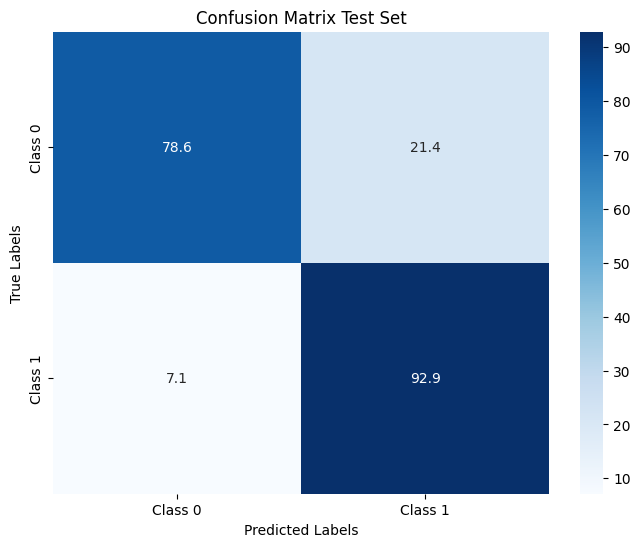

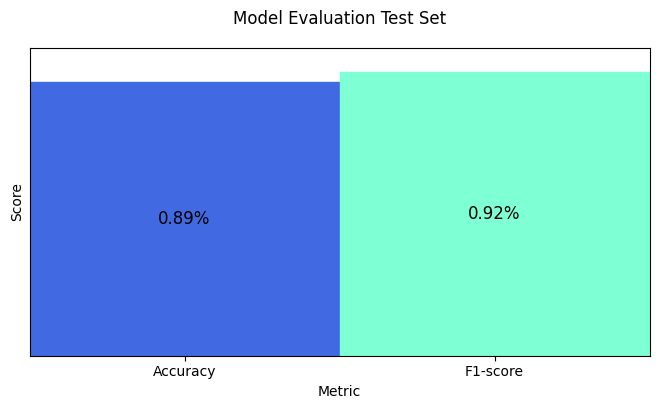

Accuracy:  0.8877551020408163
Precision:  0.9154929577464789
Recall:  0.9285714285714286
F1:  0.921985815602837


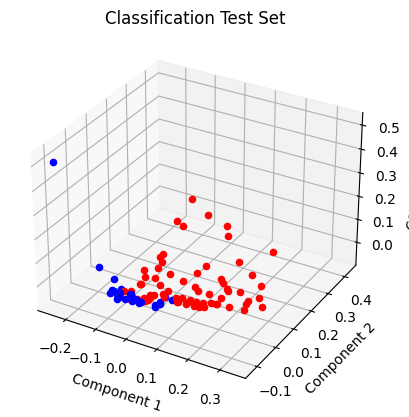

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model_name = "neural_networks"

# Initialize and train the MLP classifier
mlp_classifier = MLPClassifier()
mlp_classifier.fit(pca_vectors_train, train_labels)

# Predict the labels for the train and validation sets
predicted_labels_train = mlp_classifier.predict(pca_vectors_train)
predicted_labels_val = mlp_classifier.predict(pca_vectors_val)
predicted_labels_test = mlp_classifier.predict(pca_vectors_test)


# Print the confusion matrix for the validation set
print("Confusion Matrix - Test Set:")
create_confusion_matrix(test_labels, predicted_labels_test, "Test Set", model_name=model_name)

# Sjhut utp

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def generate_word_cloud(tweets):
    # Concatenate all the tweets into a single string
    text = ' '.join(tweets)

    # Generate the word cloud
    wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(text)

    # Display the word cloud
    plt.figure(figsize=(14, 12), dpi=200)
    plt.imshow(wordcloud, interpolation='kaiser')
    plt.axis('off')
    plt.show()
    return wordcloud

In [ ]:
user_replies = get_users_pp_type_x(users_pp_typed_documents, type_x = "replies")

Len:  982


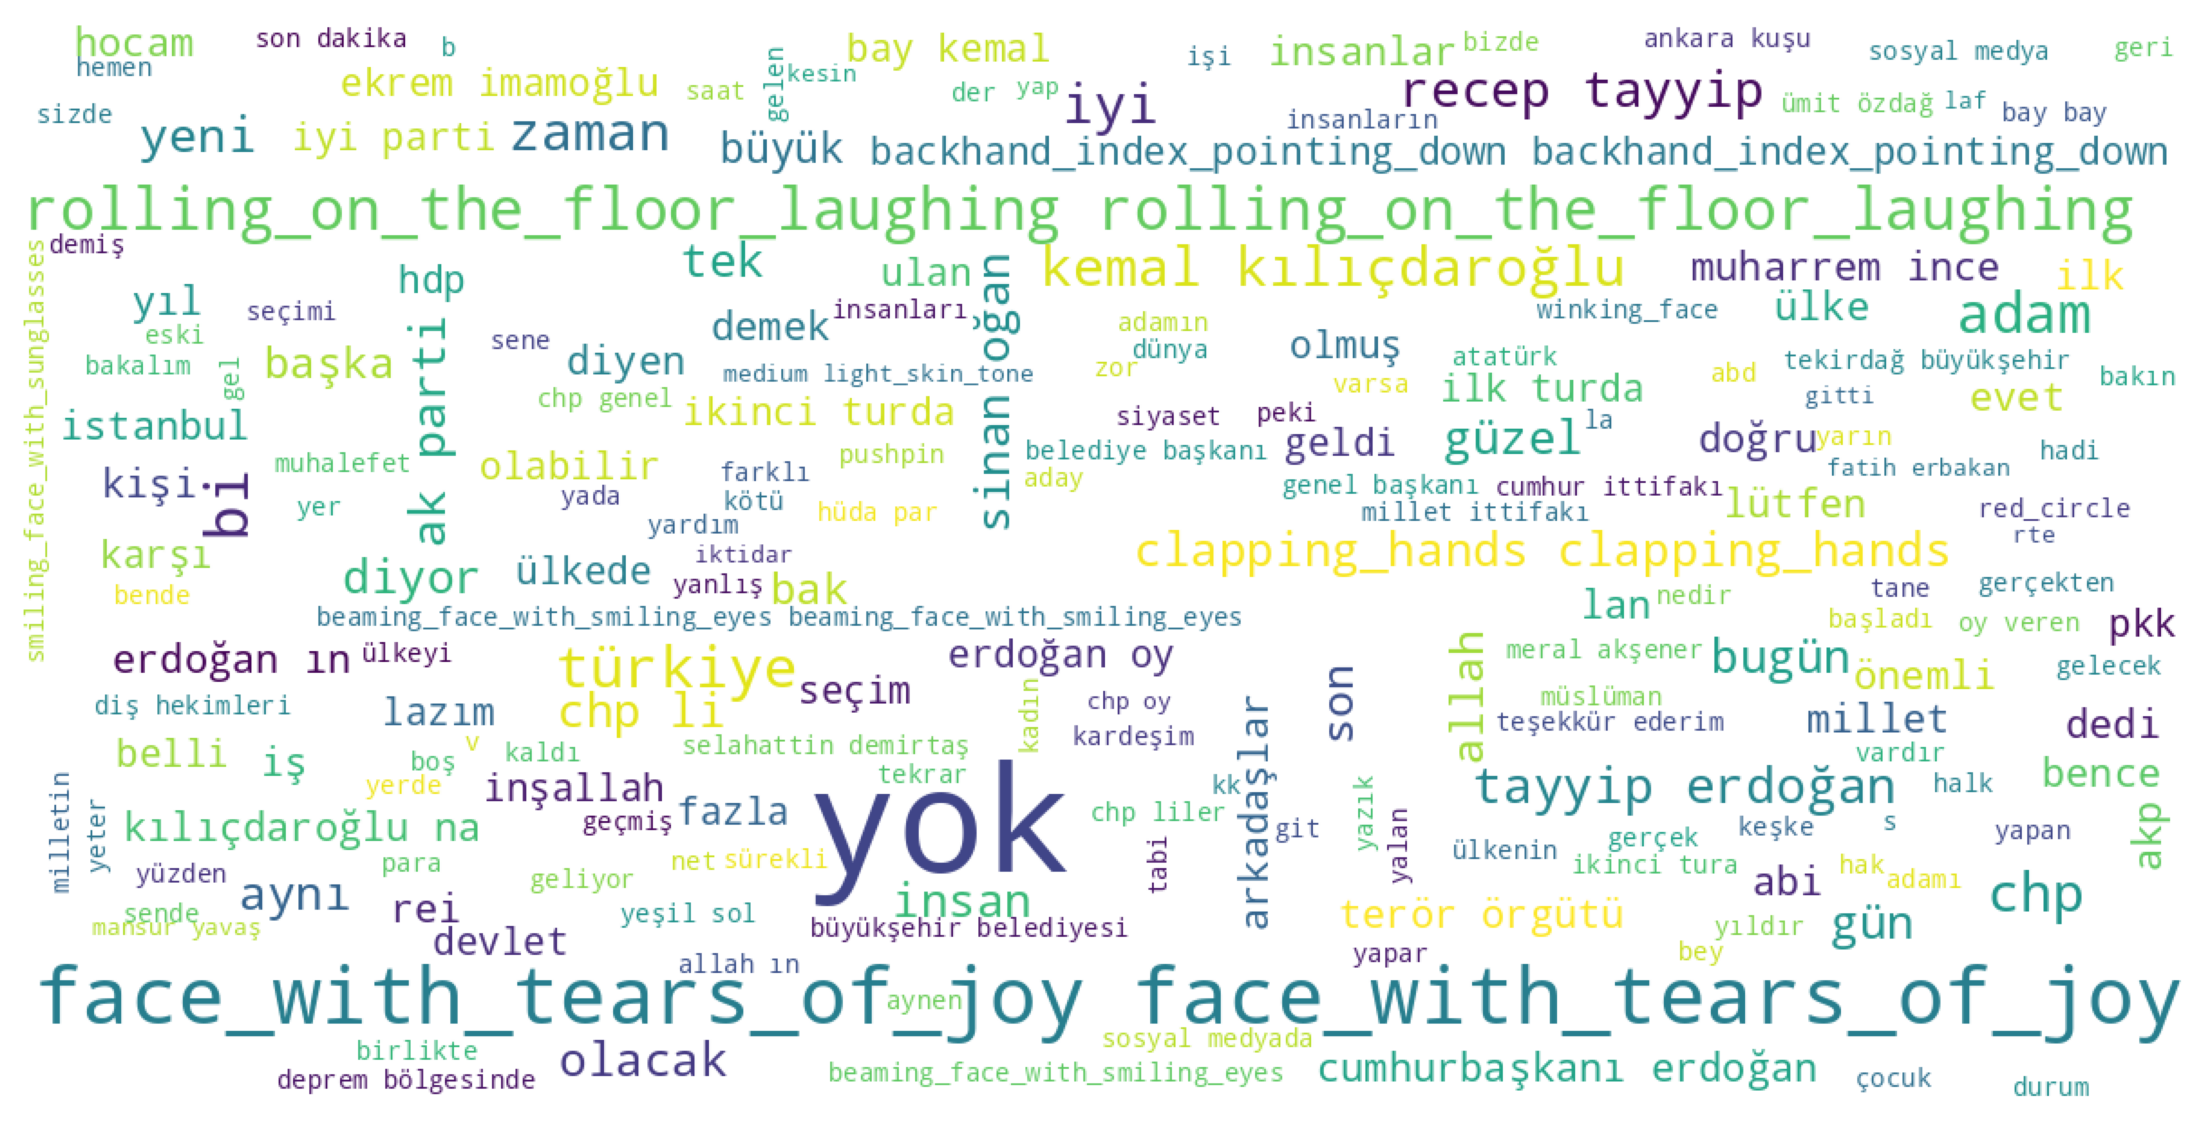

In [ ]:
wordcloud = generate_word_cloud(users_pp_documents.values())

In [ ]:
users_pp_documents['1004046890596528129']

'fetönün porno montajlarıyla genel başkanlık koltuğuna oturmuş rakibi muharrem inceye montaj kasetlerle şantaj yapmış sahtekar fazla beylik laflar ediyorsun kemal seçmenin partin nefret hafta koltuğunu karar esasen temele dayanıyor başvurucu kollukta programı indirdim demiş yargılamada söylemedim kolluk yanlış yazmış programı indirmedim kullanmadım demiş tespit tutanağı dosyaya gelmediği ihlal kararı verilmiş ihlal kararı gerekçeli yemin ediyorum kayseri yaşlı teyzeler hastalar sandığa sürünerek geldiler ambulansla geldi yetmedi uyardık dışarıda oy kullanılamaz adamı sedyeyle üst kata çıkardılar yetmedi yabancı uyruklular nefes nefese koştular yetmedi yaşlı yaşlı insanlar oy sayımında yiyin efendiler yiyin hanı iştiha doyunca tıksırınca çatlayıncaya yiyin sinan oğan saldıran 60 akp milletvekiline akit ler demişti dayak yiyen katıldı işinin ehli iktisatçı ekonomistler kılıçdaroğlu kazanamadığı taktirde ekonomik kriz ekonomik buhran tsunaminin bizleri beklediğini söylüyor neler yaşanılac

### SVMs Old

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
import numpy as np

PCA_ENABLED = True

# Collect the train texts and labels from the tfidf_user_train dictionary
train_texts = []
train_labels = []
for user_id, user_data in tfidf_user_train.items():
    train_texts.append(user_data['text'])
    train_labels.append(user_data['label'])

# Collect the validation texts and labels from the tfidf_user_val dictionary
val_texts = []
val_labels = []
for user_id, user_data in tfidf_user_val.items():
    val_texts.append(user_data['text'])
    val_labels.append(user_data['label'])

# Define the different PCA components values to try
pca_components = [3, 20, 40, 80, 200, 500, 728]

# Create arrays to store the accuracies
train_accuracies = np.zeros(len(pca_components))
val_accuracies = np.zeros(len(pca_components))

for i, n_components in enumerate(pca_components):
    # Apply PCA to reduce the dimensionality of the TF-IDF vectors (optional)
    pca = PCA(n_components=n_components)
    train_pca_vectors = pca.fit_transform(train_tfidf_vectors.toarray())
    val_pca_vectors = pca.transform(val_tfidf_vectors.toarray())

    # Normalize the vectors
    normalizer = Normalizer(norm='l2')
    train_pca_vectors = normalizer.fit_transform(train_pca_vectors)
    val_pca_vectors = normalizer.fit_transform(val_pca_vectors)

    # Use PCA vectors for SVM training
    svm_train_vectors = train_pca_vectors
    svm_val_vectors = val_pca_vectors

    # Create an SVM classifier
    svm = SVC(C=1, kernel='rbf', gamma=1)

    # Train the SVM classifier on the train vectors and labels
    svm.fit(svm_train_vectors, train_labels)

    # Make predictions on the train and validation vectors
    train_predictions = svm.predict(svm_train_vectors)
    val_predictions = svm.predict(svm_val_vectors)

    # Evaluate the accuracy of the classifier on train and validation sets
    train_accuracy = accuracy_score(train_labels, train_predictions)
    val_accuracy = accuracy_score(val_labels, val_predictions)

    # Save the accuracies
    train_accuracies[i] = train_accuracy
    val_accuracies[i] = val_accuracy

    # ... Rest of the code for plotting and displaying results

# Print the accuracies
for i, n_components in enumerate(pca_components):
    print(f"PCA Components: {n_components}")
    print("Train Accuracy:", train_accuracies[i])
    print("Validation Accuracy:", val_accuracies[i])
    print()


KeyboardInterrupt: ignored

In [ ]:
len(tfidf_user_val.values())-1/len(tfidf_user_val.values())

95.98958333333333

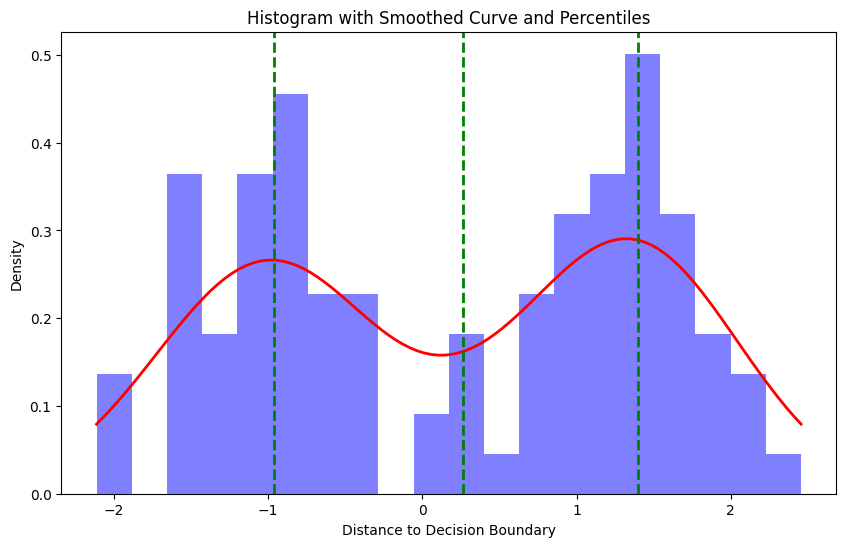

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Compute distances to decision boundary for all samples in the validation set
distances = svm.decision_function(svm_val_vectors)

# Calculate percentiles
percentiles = np.percentile(distances, [25, 50, 75])

# Create a histogram of distances with a smoothed curve
plt.figure(figsize=(10, 6))
plt.hist(distances, bins=20, density=True, alpha=0.5, color='blue')

# Compute the kernel density estimate (KDE) for the distances
kde = gaussian_kde(distances)
x_vals = np.linspace(distances.min(), distances.max(), 100)
smoothed_curve = kde(x_vals)

# Plot the smoothed curve
plt.plot(x_vals, smoothed_curve, color='red', linewidth=2)

# Add vertical lines for percentiles
for percentile in percentiles:
    plt.axvline(x=percentile, color='green', linestyle='--', linewidth=2)

# Set labels and title for the plot
plt.xlabel('Distance to Decision Boundary')
plt.ylabel('Density')
plt.title('Histogram with Smoothed Curve and Percentiles')

# Show the plot
plt.show()

for i,(k,v) in enumerate(tfidf_user_val.items()):
  if val_predictions[i] != v['label']:
    print(i, k,f"True label {v['label']}", f"Prediction {val_predictions[i]}", account_id_screen_name[k])

### Neural Net

In [ ]:
import numpy as np
dimensions = 500
# Convert TF-IDF vectors to NumPy arrays
train_vectors = train_tfidf_vectors.toarray()
val_vectors = val_tfidf_vectors.toarray()

# Apply PCA to reduce the dimensionality of the TF-IDF vectors to 200 for both train and validation sets
pca = PCA(n_components=dimensions)
train_pca_vectors = pca.fit_transform(train_vectors)
val_pca_vectors = pca.transform(val_vectors)

# Convert labels to NumPy arrays
train_labels = np.array(train_labels)
val_labels = np.array(val_labels)

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from tensorflow.keras import regularizers
from sklearn.decomposition import PCA
from tensorflow.keras import optimizers, losses, metrics
from tensorflow.keras.callbacks import ModelCheckpoint

log_dir = f"{HOME_PATH}/neural_model_1"
checkpoint_path = f"{HOME_PATH}/neural_model_1/best_model.h5"

#-------------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Flatten

# Define the SelfAttention layer
class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, attention_units):
        super(SelfAttention, self).__init__()
        self.attention_units = attention_units

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], self.attention_units),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(shape=(self.attention_units,),
                                 initializer='zeros',
                                 trainable=True)
        self.V = self.add_weight(shape=(self.attention_units, 1),
                                 initializer='random_normal',
                                 trainable=True)

    def call(self, inputs):
        query = tf.matmul(inputs, self.W) + self.b
        score = tf.matmul(tf.nn.tanh(query), self.V)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        return tf.reduce_sum(context_vector, axis=1)

# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=dimensions, kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.2),
    SelfAttention(64),
    Flatten(),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.7),
    SelfAttention(32),
    Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.7),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

#-------------------------------------------------------------------------------
learning_rate = 0.001
model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
              loss=losses.BinaryCrossentropy(from_logits=False),
              metrics=[metrics.BinaryAccuracy(), metrics.Precision(), metrics.Recall(), metrics.AUC()])

# Assuming you have train_features, train_labels, val_features, and val_labels

checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_binary_accuracy', save_best_only=True, mode='max', verbose=1)

history = model.fit(train_pca_vectors, train_labels,
                    validation_data=(val_pca_vectors, val_labels),
                    epochs=200,
                    batch_size=8,
                    callbacks=[tf.keras.callbacks.TensorBoard(log_dir=log_dir)])

# Make predictions on the train and validation sets
train_predictions = model.predict(train_pca_vectors)
val_predictions = model.predict(val_pca_vectors)

# Convert predictions to binary values
train_predictions = np.where(train_predictions > 0.5, 1, 0)
val_predictions = np.where(val_predictions > 0.5, 1, 0)

# Calculate accuracies
train_accuracy = accuracy_score(train_labels, train_predictions)
val_accuracy = accuracy_score(val_labels, val_predictions)

# Print the accuracies
print("Train Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)


Epoch 1/200
98/98 [==============================] - 2s 7ms/step - loss: 2.4869 - binary_accuracy: 0.5153 - precision: 0.5655 - recall: 0.6726 - auc: 0.4843 - val_loss: 1.7475 - val_binary_accuracy: 0.5417 - val_precision: 0.5417 - val_recall: 1.0000 - val_auc: 0.5363
Epoch 2/200
98/98 [==============================] - 0s 3ms/step - loss: 1.3634 - binary_accuracy: 0.5703 - precision: 0.5737 - recall: 0.9800 - auc: 0.5392 - val_loss: 1.0893 - val_binary_accuracy: 0.5417 - val_precision: 0.5417 - val_recall: 1.0000 - val_auc: 0.5673
Epoch 3/200
98/98 [==============================] - 0s 4ms/step - loss: 0.9438 - binary_accuracy: 0.5729 - precision: 0.5736 - recall: 0.9978 - auc: 0.6522 - val_loss: 0.7918 - val_binary_accuracy: 0.5417 - val_precision: 0.5417 - val_recall: 1.0000 - val_auc: 0.9895
Epoch 4/200
98/98 [==============================] - 0s 4ms/step - loss: 0.7359 - binary_accuracy: 0.6777 - precision: 0.6442 - recall: 0.9800 - auc: 0.8929 - val_loss: 0.6134 - val_binary_accu

KeyboardInterrupt: ignored

In [ ]:
# Access the validation loss and accuracy per epoch from the history object
val_loss = history.history['val_loss']
val_accuracy = history.history['val_binary_accuracy']
train_loss = history.history['loss']
train_accuracy = history.history['binary_accuracy']

# Plot the validation and training metrics
epochs = range(1, len(val_loss) + 1)

plt.figure(figsize=(12, 4))

# Plot validation loss
plt.subplot(1, 2, 1)
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.plot(epochs, train_loss, 'r', label='Training Loss')
plt.title('Validation and Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.plot(epochs, train_accuracy, 'r', label='Training Accuracy')
plt.title('Validation and Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()